# 02 — Analyse Exploratoire des Données (EDA)
## Projet : Détection de Phishing par Machine Learning
**ENSAT Tétouan | GI2 | 2025-2026**

---

**Objectif de ce notebook :**  
Réaliser une analyse exploratoire complète du dataset `data/dataset.parquet` pour :
- Comprendre la distribution de chaque variable (univarié)
- Identifier les features potentiellement prédictives de `is_phishing` (bivarié)
- Analyser le déséquilibre de classes et repérer les "features signaux"

**Structure :**
1. Setup & Chargement
2. Exploration Univariée
3. Exploration Bivariée
4. Analyse du Déséquilibre de Classes
5. Synthèse

---
## 0. Setup & Chargement

In [1]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ─── Style global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2d3154',
    'axes.labelcolor': '#e2e8f0',
    'axes.titlecolor': '#f8fafc',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',
    'grid.color': '#2d3154',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Palette de couleurs du projet
COLORS = {
    'legitime':  '#4ade80',   # vert
    'phishing':  '#f87171',   # rouge
    'primary':   '#818cf8',   # violet
    'secondary': '#38bdf8',   # bleu
    'accent':    '#fb923c',   # orange
    'gradient':  ['#4ade80', '#a3e635', '#facc15', '#fb923c', '#f87171'],
}
CLASS_COLORS  = [COLORS['legitime'], COLORS['phishing']]
CLASS_LABELS  = {0: 'Légitime', 1: 'Phishing'}

# ─── Dossier de figures ────────────────────────────────────────────────────────
FIG_DIR = Path('../figures/eda')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight',
                facecolor=plt.rcParams['figure.facecolor'])
    plt.show()

print('✅ Setup complet — librairies chargées.')

✅ Setup complet — librairies chargées.


In [2]:
# ─── Chargement du dataset ─────────────────────────────────────────────────────
df = pd.read_parquet('../data/dataset.parquet')

# Colonnes feature / identifiant / cible
TARGET  = 'is_phishing'
ID_COL  = 'url'

NUM_FEATURES = [
    'url_length', 'domain_length', 'num_dots', 'num_subdomains',
    'num_hyphens', 'num_underscores', 'num_at_signs',
    'path_length', 'domain_age_days', 'brand_similarity'
]
BINARY_FEATURES = ['has_port', 'has_https', 'has_http_in_domain', 'has_valid_ssl']
CAT_FEATURES    = ['country']

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\nTypes de données :')
print(df.dtypes)
print(f'\nValeurs manquantes : {df.isnull().sum().sum()} (aucune NaN)')

Dimensions : 11,000 lignes × 17 colonnes

Types de données :
url                       str
is_phishing             int64
url_length              int64
domain_length           int64
num_dots                int64
num_subdomains          int64
num_hyphens             int64
num_underscores         int64
num_at_signs            int64
has_port                int64
has_https               int64
has_http_in_domain      int64
path_length             int64
domain_age_days         int64
country                   str
has_valid_ssl           int64
brand_similarity      float64
dtype: object

Valeurs manquantes : 0 (aucune NaN)


In [3]:
# Aperçu des premières lignes
df.drop(columns=[ID_COL]).head(5)

,is_phishing,url_length,domain_length,num_dots,num_subdomains,num_hyphens,num_underscores,num_at_signs,has_port,has_https,has_http_in_domain,path_length,domain_age_days,country,has_valid_ssl,brand_similarity
0,1,68,24,2,1,1,0,0,0,1,0,22,1,UNKNOWN,1,0.3158
1,1,42,35,2,1,1,0,0,0,0,0,0,0,PL,1,0.4348
2,1,44,37,2,1,1,0,0,0,0,0,0,-1,PL,1,0.4348
3,1,42,35,2,1,0,0,0,0,0,0,0,1,PL,1,0.4348
4,1,37,30,2,1,1,0,0,0,0,0,0,13,PL,1,0.4348


---
## 1. Exploration Univariée
### 1.1 Variables Numériques — Statistiques Descriptives

In [4]:
# Statistiques descriptives complètes pour les variables continues
desc = df[NUM_FEATURES + BINARY_FEATURES].describe(percentiles=[.25, .5, .75]).T
desc.columns = ['N', 'Moyenne', 'Écart-type', 'Min', 'Q1 (25%)', 'Médiane', 'Q3 (75%)', 'Max']
desc['Étendue'] = desc['Max'] - desc['Min']
desc['IQR'] = desc['Q3 (75%)'] - desc['Q1 (25%)']

print('='*90)
print('STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES')
print('='*90)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
display(desc)

STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES


,N,Moyenne,Écart-type,Min,Q1 (25%),Médiane,Q3 (75%),Max,Étendue,IQR
url_length,11000.000,25.298,26.910,12.000,17.000,20.000,25.000,1159.000,1147.000,8.000
domain_length,11000.000,14.289,8.353,4.000,9.000,12.000,16.000,84.000,80.000,7.000
num_dots,11000.000,1.258,0.566,1.000,1.000,1.000,1.000,9.000,8.000,0.000
num_subdomains,11000.000,0.232,0.463,0.000,0.000,0.000,0.000,6.000,6.000,0.000
num_hyphens,11000.000,0.274,1.098,0.000,0.000,0.000,0.000,37.000,37.000,0.000
num_underscores,11000.000,0.012,0.179,0.000,0.000,0.000,0.000,8.000,8.000,0.000
num_at_signs,11000.000,0.001,0.029,0.000,0.000,0.000,0.000,1.000,1.000,0.000
path_length,11000.000,1.861,9.215,0.000,0.000,0.000,0.000,215.000,215.000,0.000
domain_age_days,11000.000,6658.000,4452.594,-1.000,2041.000,7913.000,10455.000,15087.000,15088.000,8414.000
brand_similarity,11000.000,0.426,0.128,0.000,0.364,0.400,0.471,1.000,1.000,0.107


### 1.2 Histogrammes & Boxplots — Variables Continues

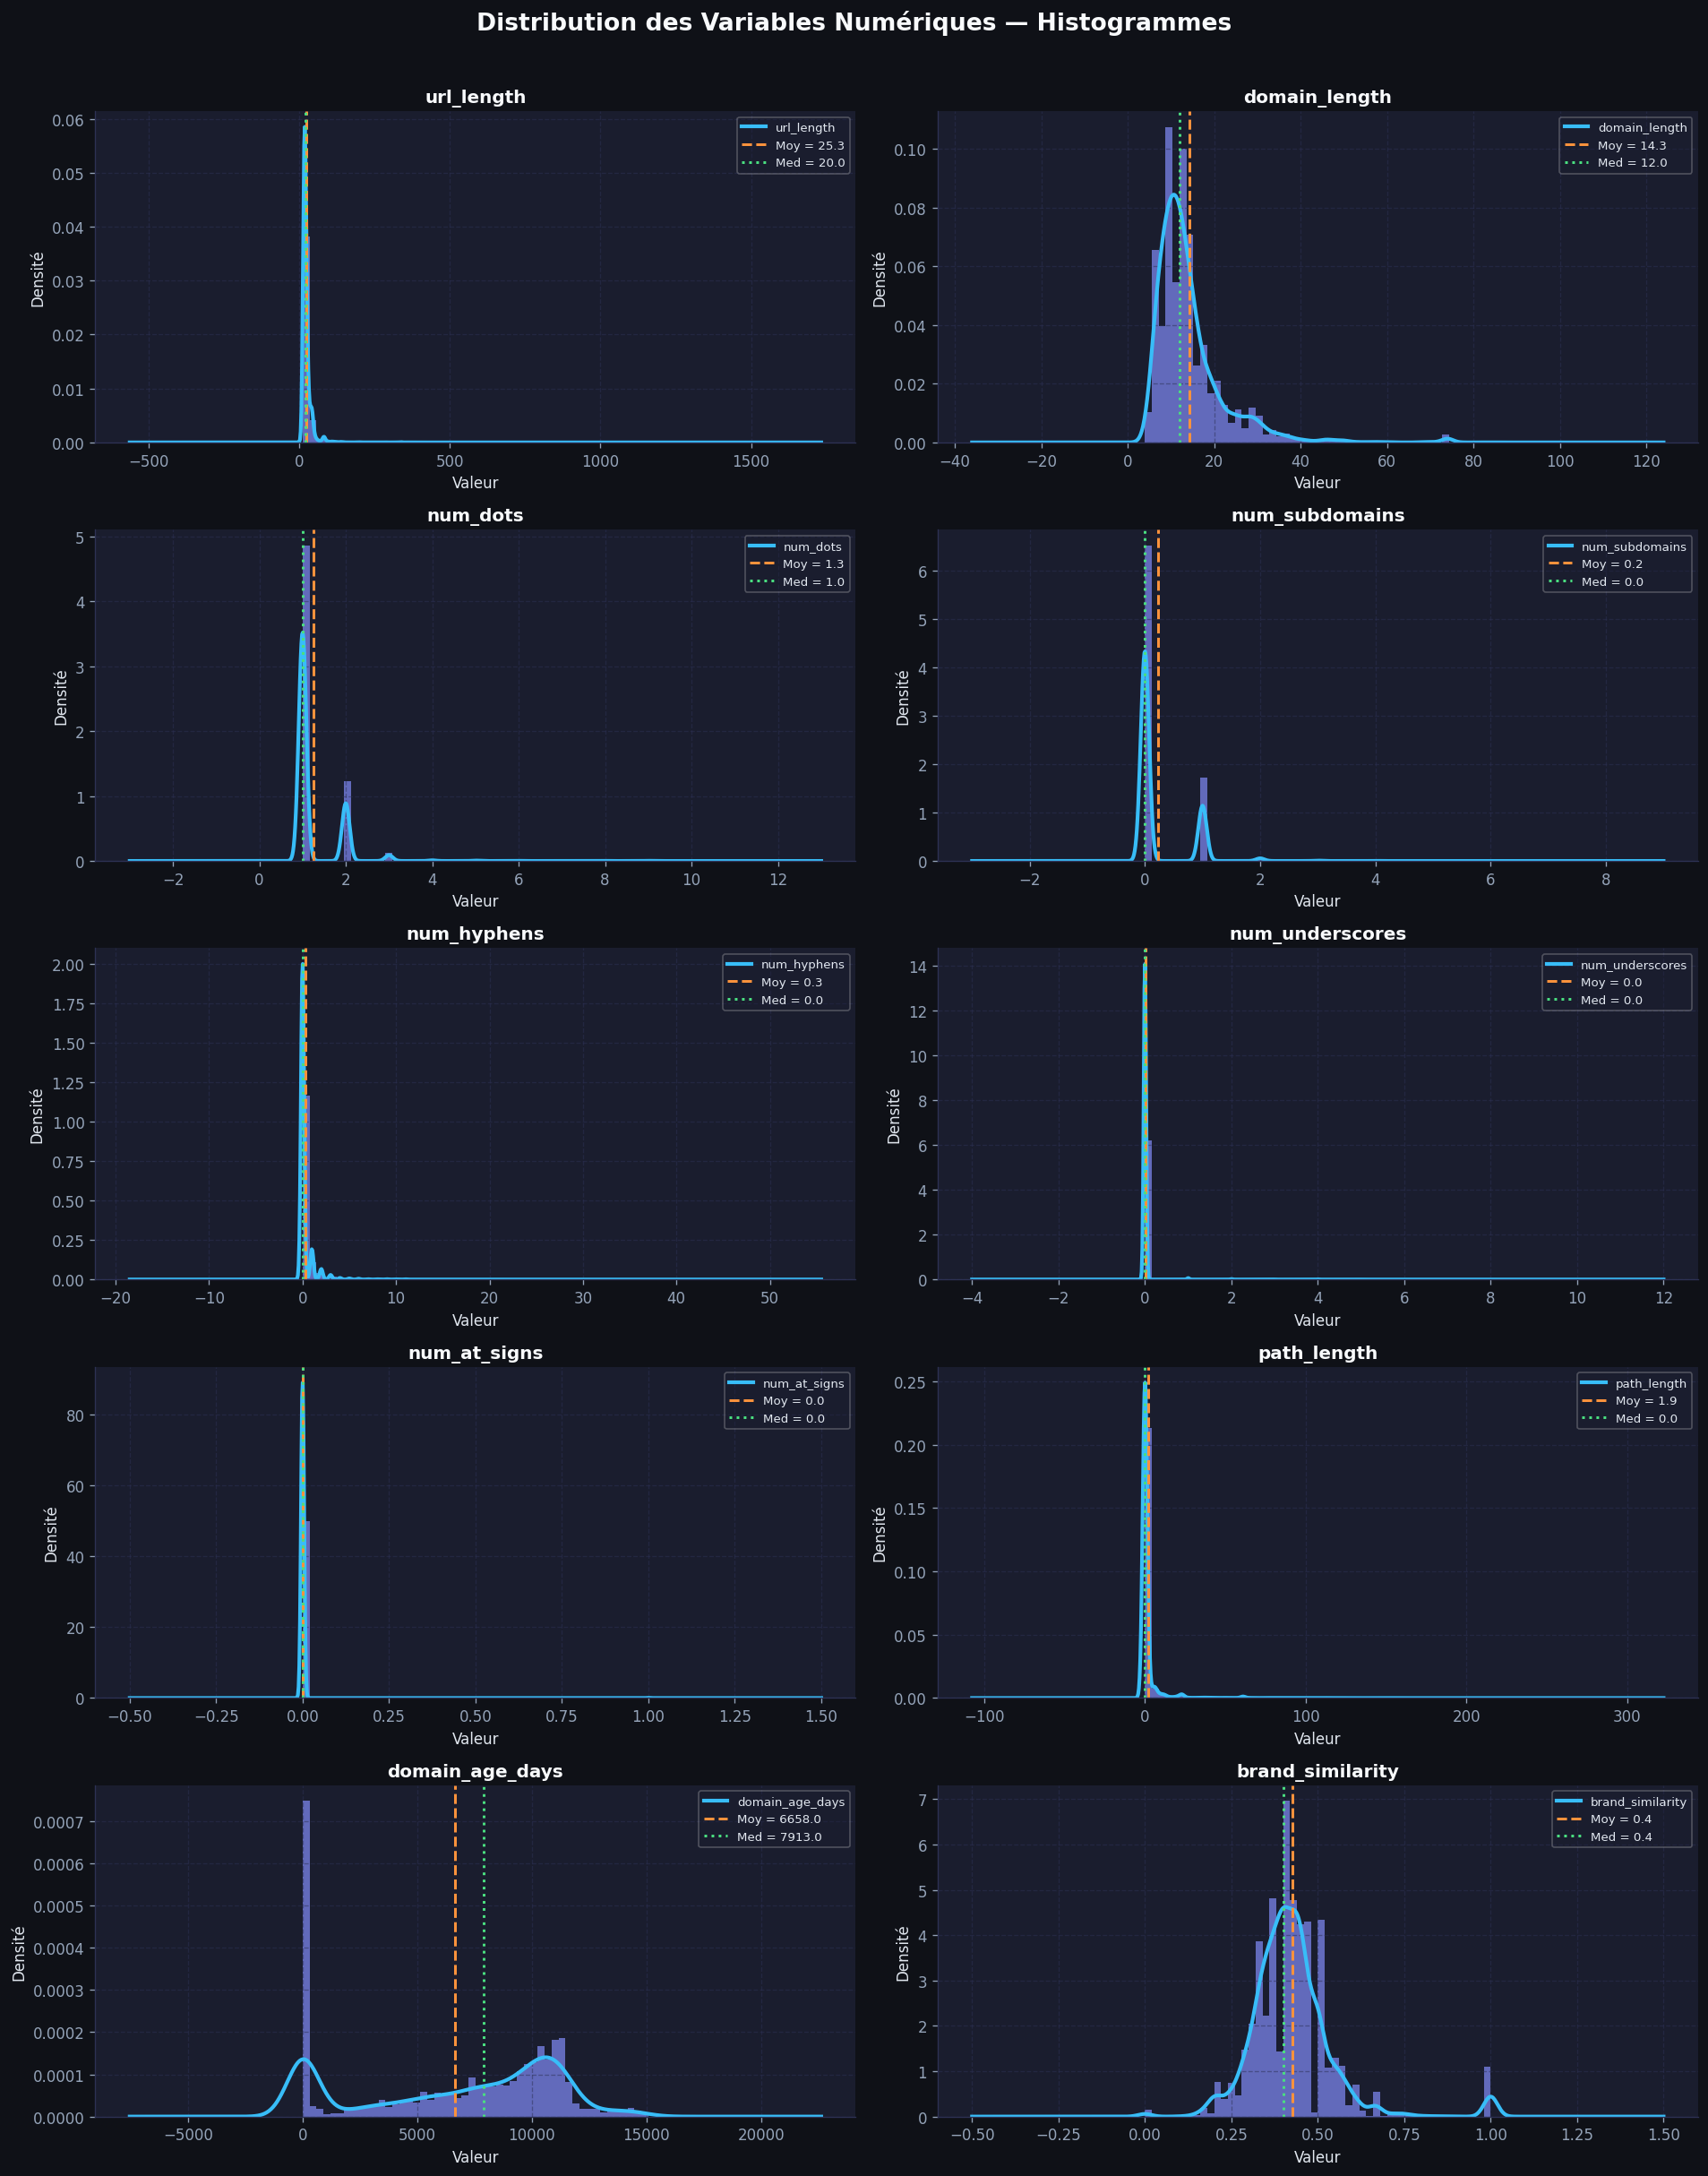

In [5]:
# ── Histogrammes des variables numériques continues ────────────────────────────
n_cols = 2
n_rows = int(np.ceil(len(NUM_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
fig.suptitle('Distribution des Variables Numériques — Histogrammes',
             fontsize=16, fontweight='bold', color='#f8fafc', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    data = df[col]
    # KDE + histogramme
    ax.hist(data, bins=50, color=COLORS['primary'], alpha=0.7, edgecolor='none', density=True)
    data.plot.kde(ax=ax, color=COLORS['secondary'], linewidth=2.5)
    
    # Lignes moyenne et médiane
    ax.axvline(data.mean(),   color=COLORS['accent'],   linestyle='--', linewidth=1.8, label=f'Moy = {data.mean():.1f}')
    ax.axvline(data.median(), color=COLORS['legitime'], linestyle=':',  linewidth=1.8, label=f'Med = {data.median():.1f}')
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True)

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
savefig('01_histogrammes_numeriques')

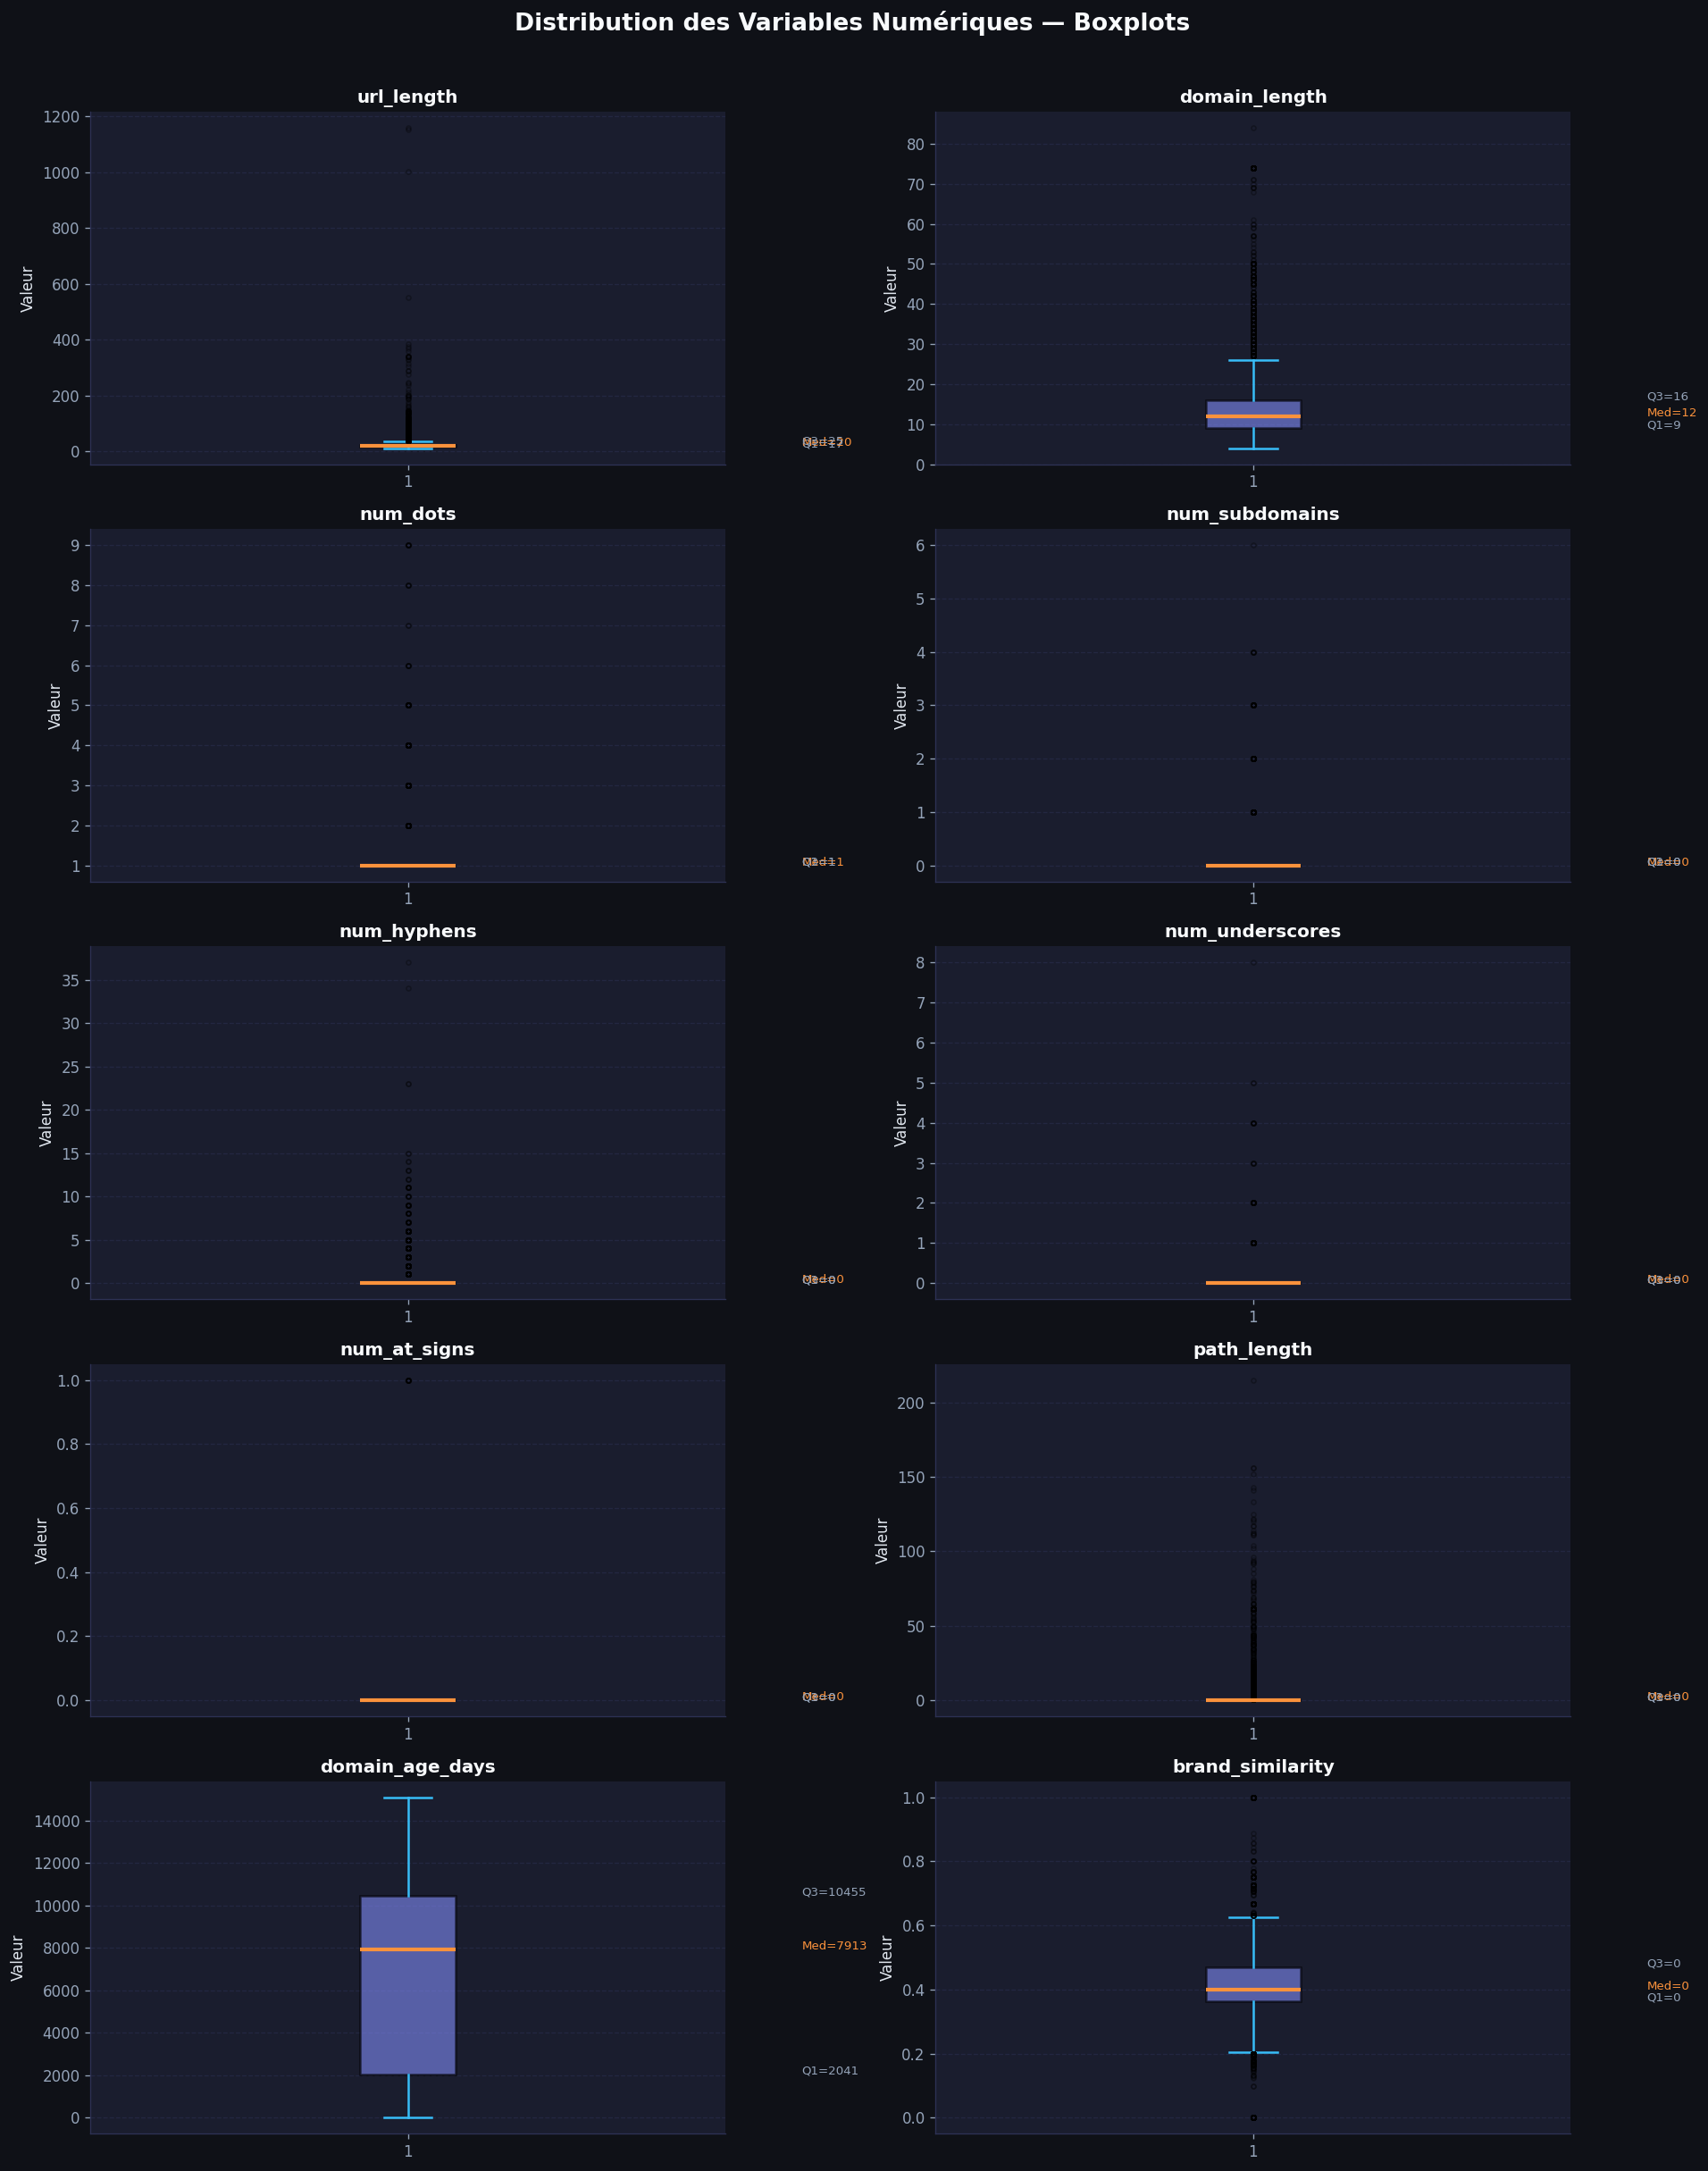

In [6]:
# ── Boxplots des variables numériques continues ────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
fig.suptitle('Distribution des Variables Numériques — Boxplots',
             fontsize=16, fontweight='bold', color='#f8fafc', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    bp = ax.boxplot(
        df[col],
        vert=True,
        patch_artist=True,
        notch=False,
        boxprops=dict(facecolor=COLORS['primary'], alpha=0.6, linewidth=1.5),
        medianprops=dict(color=COLORS['accent'], linewidth=2.5),
        whiskerprops=dict(color=COLORS['secondary'], linewidth=1.5),
        capprops=dict(color=COLORS['secondary'], linewidth=1.5),
        flierprops=dict(marker='o', color=COLORS['phishing'], alpha=0.3, markersize=3)
    )
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(True, axis='y')
    
    # Annotation Q1, Médiane, Q3
    q1  = df[col].quantile(0.25)
    med = df[col].median()
    q3  = df[col].quantile(0.75)
    ax.text(1.12, q1,  f'Q1={q1:.0f}',  transform=ax.get_yaxis_transform(), fontsize=8, color='#94a3b8')
    ax.text(1.12, med, f'Med={med:.0f}', transform=ax.get_yaxis_transform(), fontsize=8, color=COLORS['accent'])
    ax.text(1.12, q3,  f'Q3={q3:.0f}',  transform=ax.get_yaxis_transform(), fontsize=8, color='#94a3b8')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
savefig('02_boxplots_numeriques')

### 1.3 Variables Binaires — Diagrammes en Barres

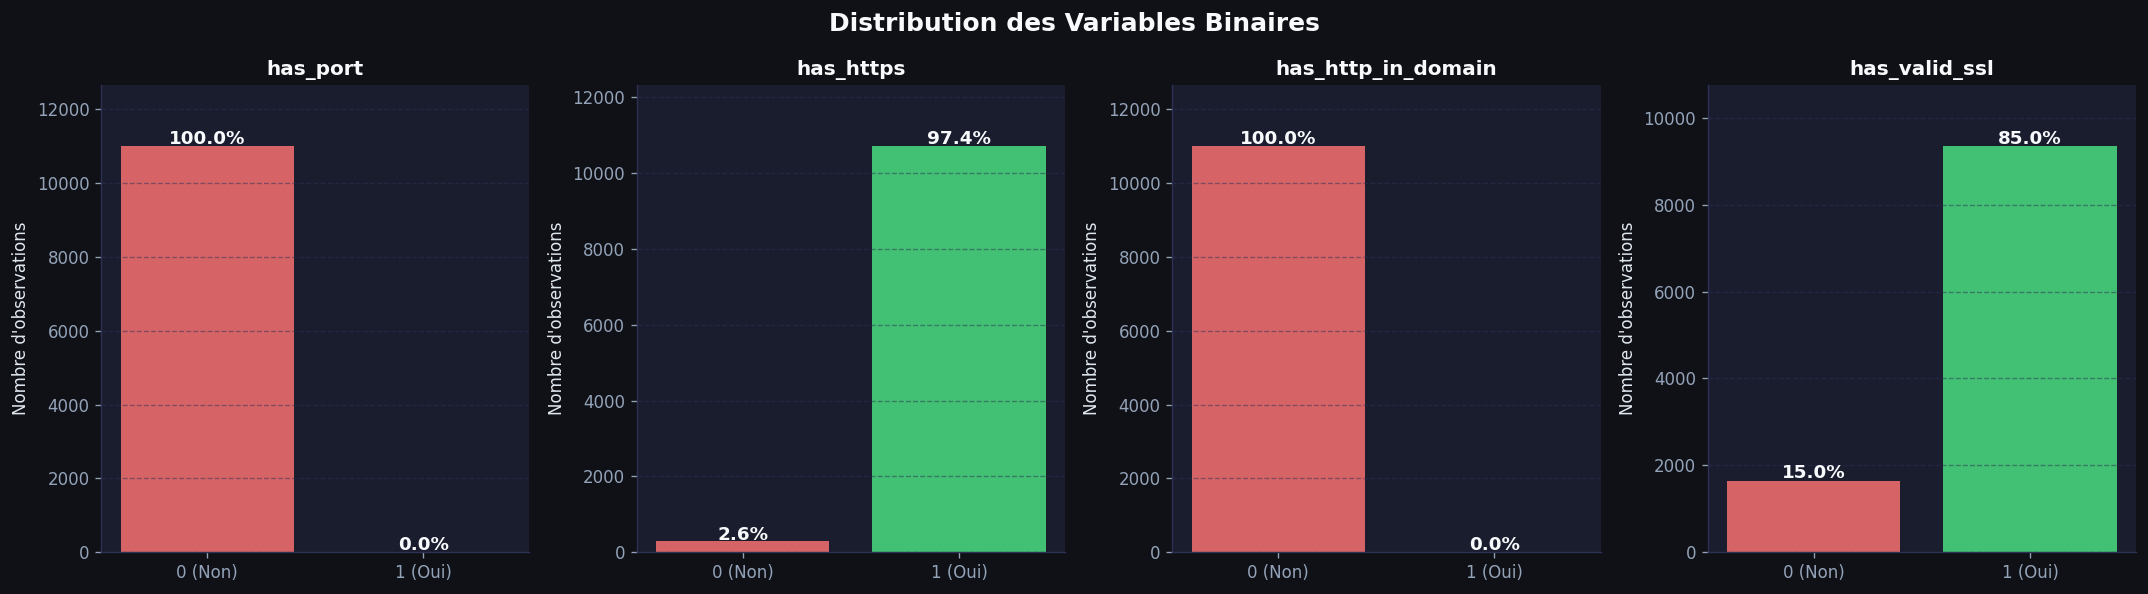

In [7]:
# ── Variables binaires (0/1) ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(BINARY_FEATURES), figsize=(18, 5))
fig.suptitle('Distribution des Variables Binaires',
             fontsize=15, fontweight='bold', color='#f8fafc')

for i, col in enumerate(BINARY_FEATURES):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    pcts   = counts / len(df) * 100
    bars   = ax.bar([f'{c} ({["Non","Oui"][c]})' for c in counts.index],
                    counts.values,
                    color=[COLORS['phishing'], COLORS['legitime']], alpha=0.85, edgecolor='none')
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#f8fafc')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Nombre d\'observations')
    ax.grid(True, axis='y')
    ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
savefig('03_variables_binaires')

### 1.4 Variable Catégorielle — `country`

In [8]:
# ── Analyse de la variable country ────────────────────────────────────────────
country_counts = df['country'].value_counts()
total = len(df)
country_pcts = country_counts / total * 100

# Modalités rares (< 1 %)
rare_modalities = country_pcts[country_pcts < 1.0]
common_modalities = country_pcts[country_pcts >= 1.0]

print(f'Nombre total de modalités : {len(country_counts)}')
print(f'Modalités fréquentes (≥ 1%) : {len(common_modalities)}')
print(f'Modalités rares (< 1%) : {len(rare_modalities)}')
print(f'\n--- Top 15 pays (fréquents) ---')
for ctry, pct in country_pcts.head(15).items():
    bar = '█' * int(pct / 0.5)
    print(f'  {ctry:<12} {pct:5.1f}%  {bar}')

Nombre total de modalités : 48
Modalités fréquentes (≥ 1%) : 3
Modalités rares (< 1%) : 45

--- Top 15 pays (fréquents) ---
  UNKNOWN       88.2%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  US             7.0%  ██████████████
  DE             2.2%  ████
  CA             0.4%  
  PL             0.4%  
  GB             0.2%  
  NL             0.2%  
  JP             0.2%  
  SG             0.1%  
  FR             0.1%  
  CN             0.1%  
  RU             0.1%  
  HK             0.1%  
  BR             0.1%  
  IT             0.1%  


In [9]:
# ── Tableau formaté des modalités rares (< 1%) ────────────────────────────────
print('='*55)
print('  MODALITÉS RARES (< 1%) — Variable `country`')
print('='*55)

rare_df = pd.DataFrame({
    'Pays (ISO)': rare_modalities.index,
    'Occurrences': country_counts[rare_modalities.index].values,
    'Pourcentage (%)': rare_modalities.values.round(3)
}).reset_index(drop=True)

rare_df.index = rare_df.index + 1   # index 1-based pour lisibilité
display(rare_df)

print(f'\n⚠️  Ces {len(rare_df)} modalités représentent chacune < 1% du dataset.')
print('   → Elles seront regroupées sous "OTHER" lors de l\'encodage pour éviter le sur-apprentissage.')

  MODALITÉS RARES (< 1%) — Variable `country`


,Pays (ISO),Occurrences,Pourcentage (%)
1,CA,42,0.382
2,PL,41,0.373
3,GB,24,0.218
4,NL,20,0.182
5,JP,20,0.182
6,SG,14,0.127
7,FR,14,0.127
8,CN,10,0.091
9,RU,10,0.091
10,HK,8,0.073



⚠️  Ces 45 modalités représentent chacune < 1% du dataset.
   → Elles seront regroupées sous "OTHER" lors de l'encodage pour éviter le sur-apprentissage.


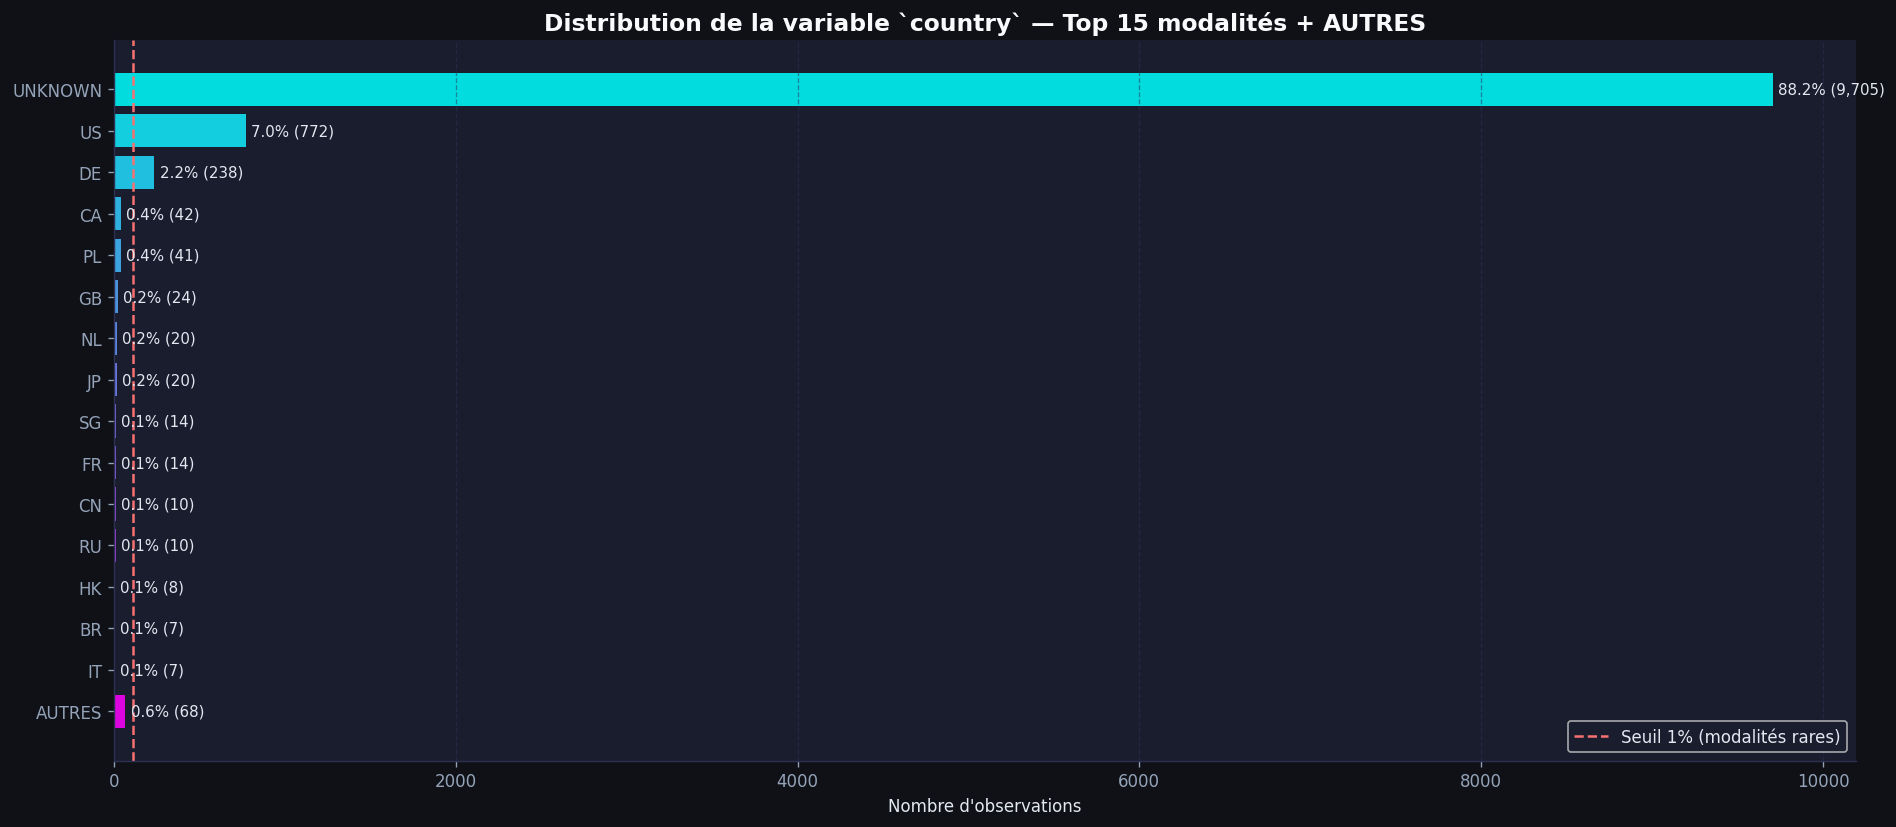

In [10]:
# ── Diagramme en barres — Top pays + AUTRES ───────────────────────────────────
top_n = 15
top_countries = country_counts.head(top_n)
other_count   = country_counts.iloc[top_n:].sum()

labels = list(top_countries.index) + (['AUTRES'] if other_count > 0 else [])
values = list(top_countries.values) + ([other_count] if other_count > 0 else [])

# Gradient de couleurs
cmap   = plt.cm.get_cmap('cool', len(labels))
colors = [cmap(i) for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.85, edgecolor='none')
for bar, val in zip(bars, values[::-1]):
    pct = val / total * 100
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}% ({val:,})', va='center', fontsize=9, color='#e2e8f0')
ax.set_title(f'Distribution de la variable `country` — Top {top_n} modalités + AUTRES',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre d\'observations')
ax.axvline(total * 0.01, color=COLORS['phishing'], linestyle='--', linewidth=1.5,
           label='Seuil 1% (modalités rares)')
ax.legend(fontsize=10)
ax.grid(True, axis='x')
plt.tight_layout()
savefig('04_country_distribution')

---
## 2. Exploration Bivariée
### 2.1 Numérique × Cible — Boxplots par Classe

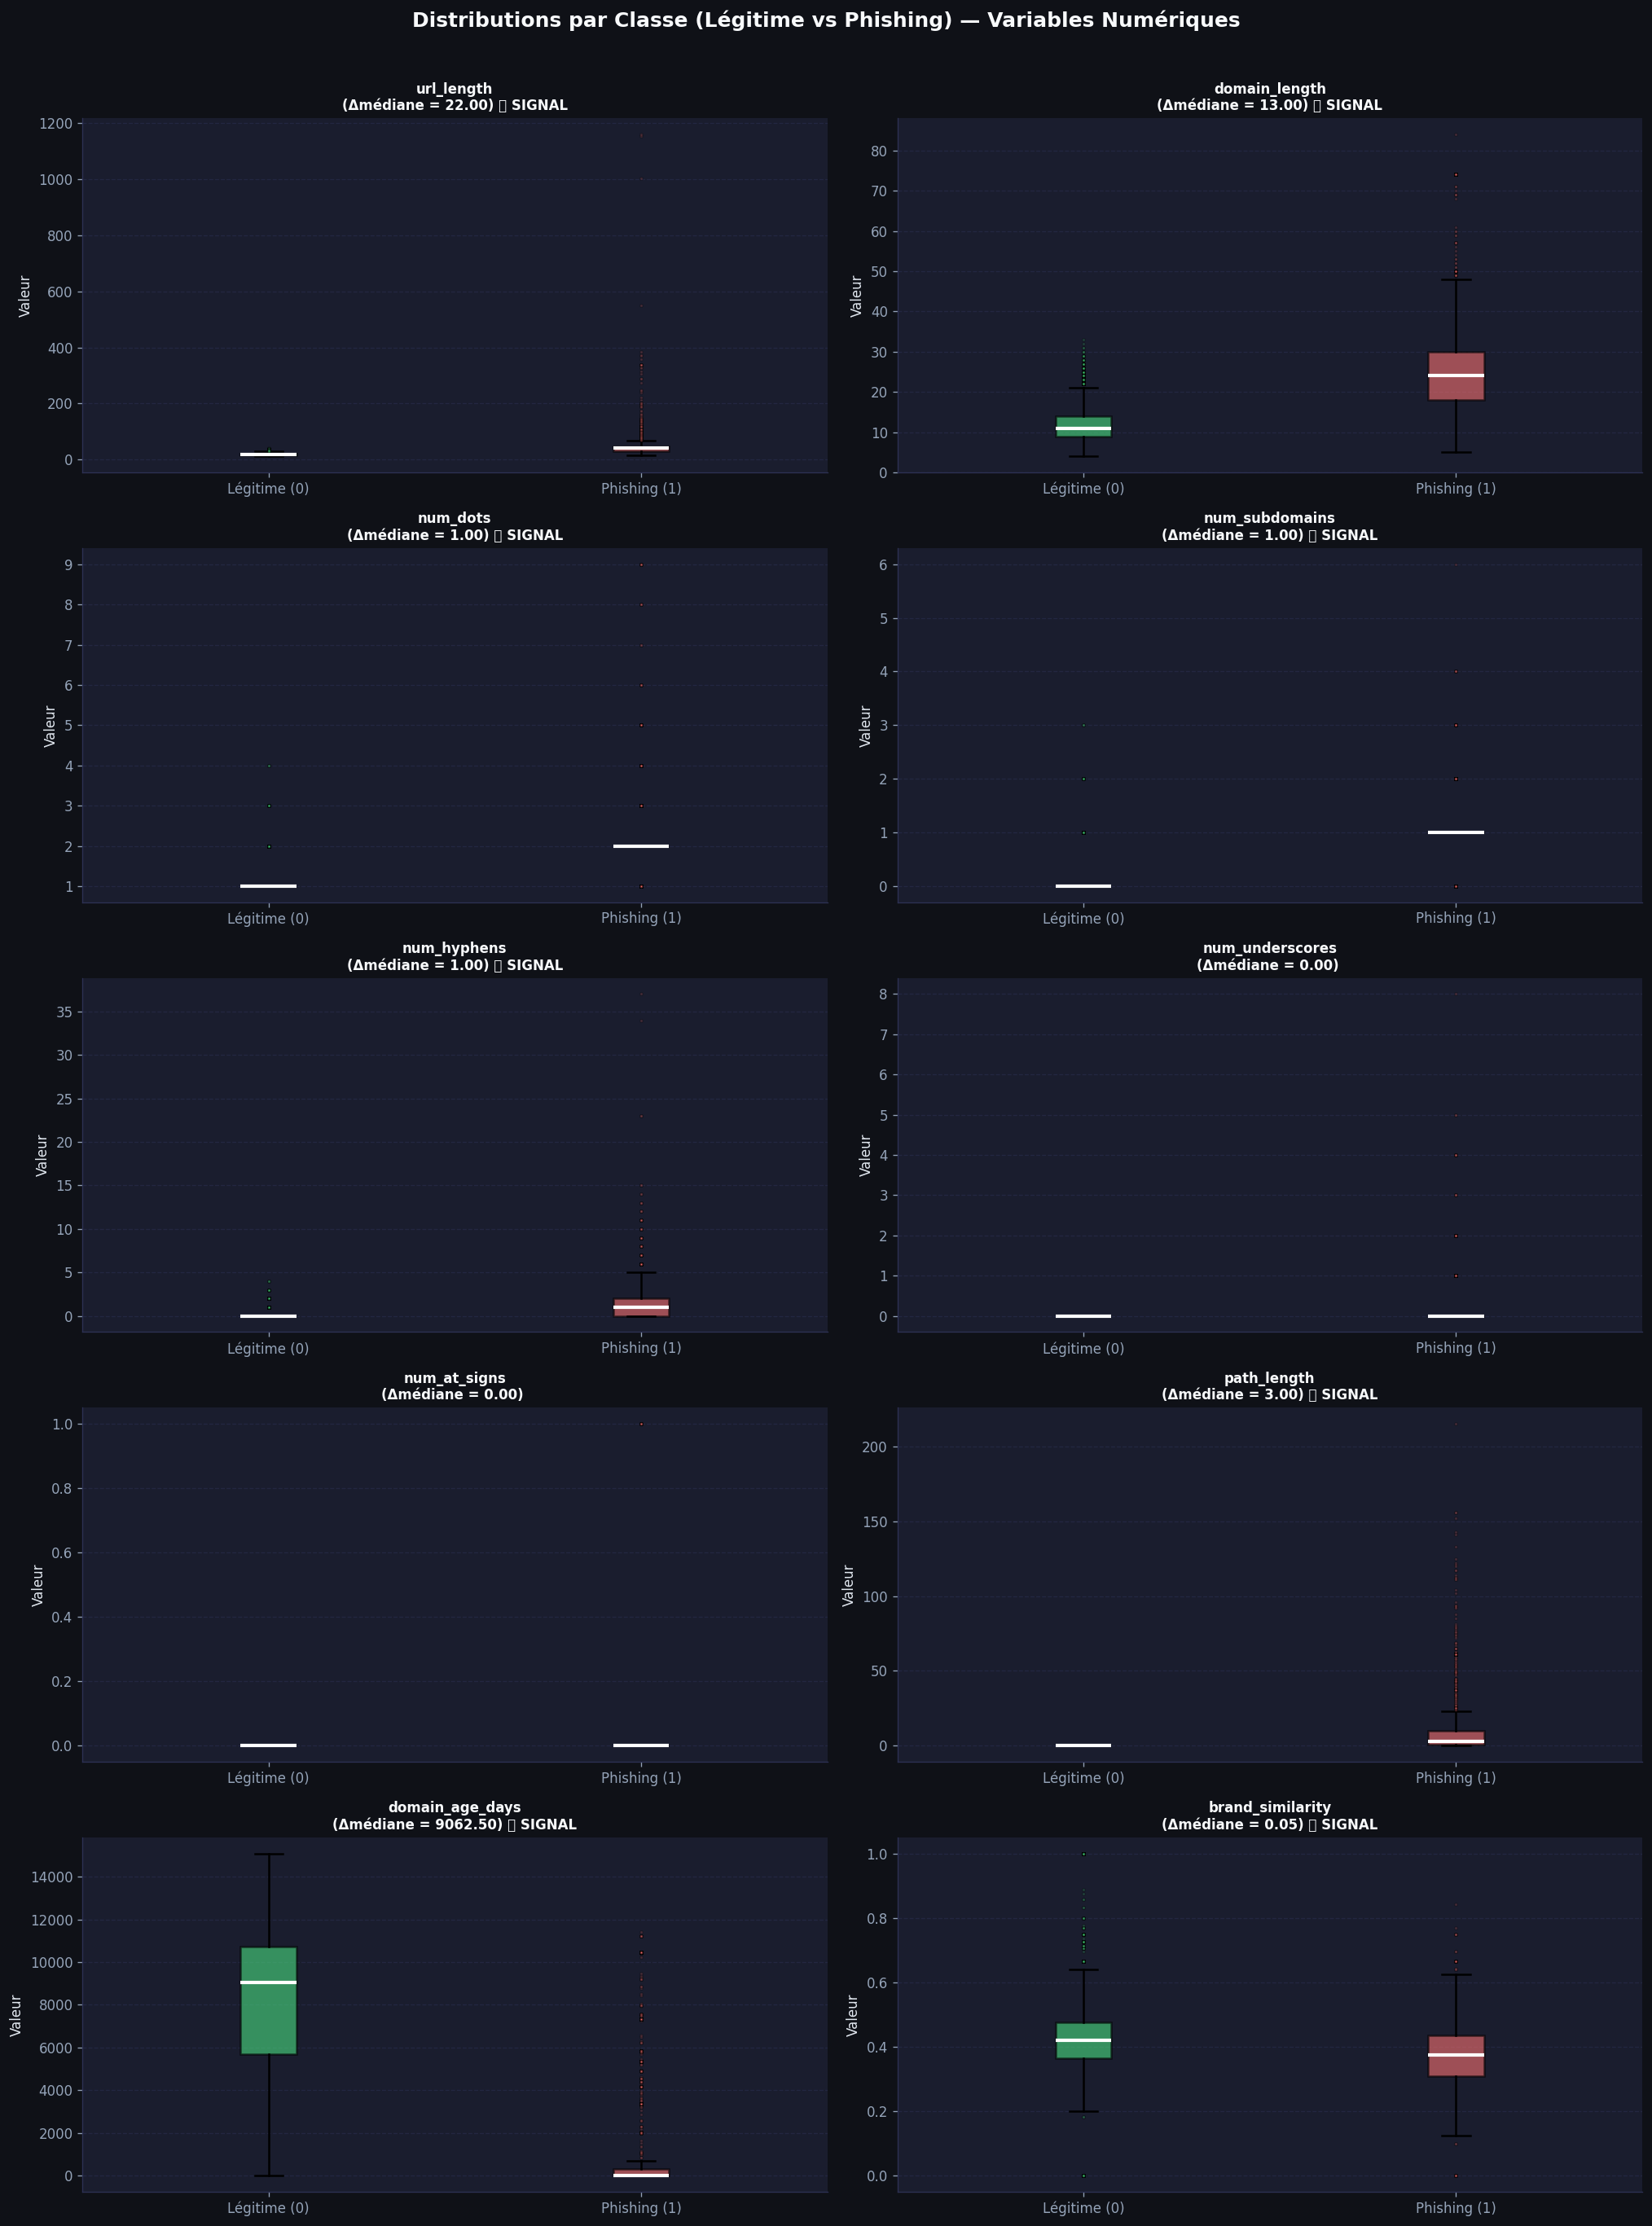

In [11]:
# ── Boxplots côte à côte : Légitime vs Phishing ────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 4.5))
fig.suptitle('Distributions par Classe (Légitime vs Phishing) — Variables Numériques',
             fontsize=15, fontweight='bold', color='#f8fafc', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    data_groups = [df[df[TARGET] == cls][col].values for cls in [0, 1]]
    bp = ax.boxplot(
        data_groups,
        labels=['Légitime (0)', 'Phishing (1)'],
        patch_artist=True,
        notch=False,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(linewidth=2.5, color='white'),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', alpha=0.2, markersize=2)
    )
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for flier, color in zip(bp['fliers'], CLASS_COLORS):
        flier.set_markerfacecolor(color)
    
    # Différence entre médianes
    med0 = df[df[TARGET] == 0][col].median()
    med1 = df[df[TARGET] == 1][col].median()
    delta = abs(med1 - med0)
    flag = '🔴 SIGNAL' if delta > 0 else ''
    ax.set_title(f'{col}\n(Δmédiane = {delta:.2f}) {flag}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(True, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
savefig('05_boxplots_par_classe')

In [12]:
# ── Tableau récapitulatif : moyennes par classe + écart ────────────────────────
stats_by_class = df.groupby(TARGET)[NUM_FEATURES + BINARY_FEATURES].mean()
stats_by_class.index = ['Légitime (0)', 'Phishing (1)']
diff = (stats_by_class.loc['Phishing (1)'] - stats_by_class.loc['Légitime (0)']).rename('Δ (Phishing − Légitime)')
diff_pct = (diff / stats_by_class.loc['Légitime (0)'].replace(0, np.nan) * 100).rename('Δ%')

summary_bivar = pd.concat([stats_by_class.T, diff, diff_pct], axis=1).round(3)
print('MOYENNES PAR CLASSE — VARIABLES NUMÉRIQUES + BINAIRES')
print('='*70)
display(summary_bivar.sort_values('Δ%', key=abs, ascending=False))

MOYENNES PAR CLASSE — VARIABLES NUMÉRIQUES + BINAIRES


,Légitime (0),Phishing (1),Δ (Phishing − Légitime),Δ%
num_hyphens,0.051,1.276,1.224,2395.543
num_subdomains,0.097,0.842,0.746,772.555
url_length,19.818,49.960,30.142,152.093
domain_length,11.818,25.406,13.588,114.975
has_http_in_domain,0.000,0.000,-0.000,-100.000
domain_age_days,7846.257,1310.840,-6535.418,-83.293
num_dots,1.097,1.986,0.890,81.158
has_valid_ssl,0.893,0.656,-0.238,-26.605
brand_similarity,0.439,0.369,-0.070,-15.904
has_https,1.000,0.857,-0.143,-14.300


### 2.2 Variables Binaires × Cible — Taux de Phishing par Modalité

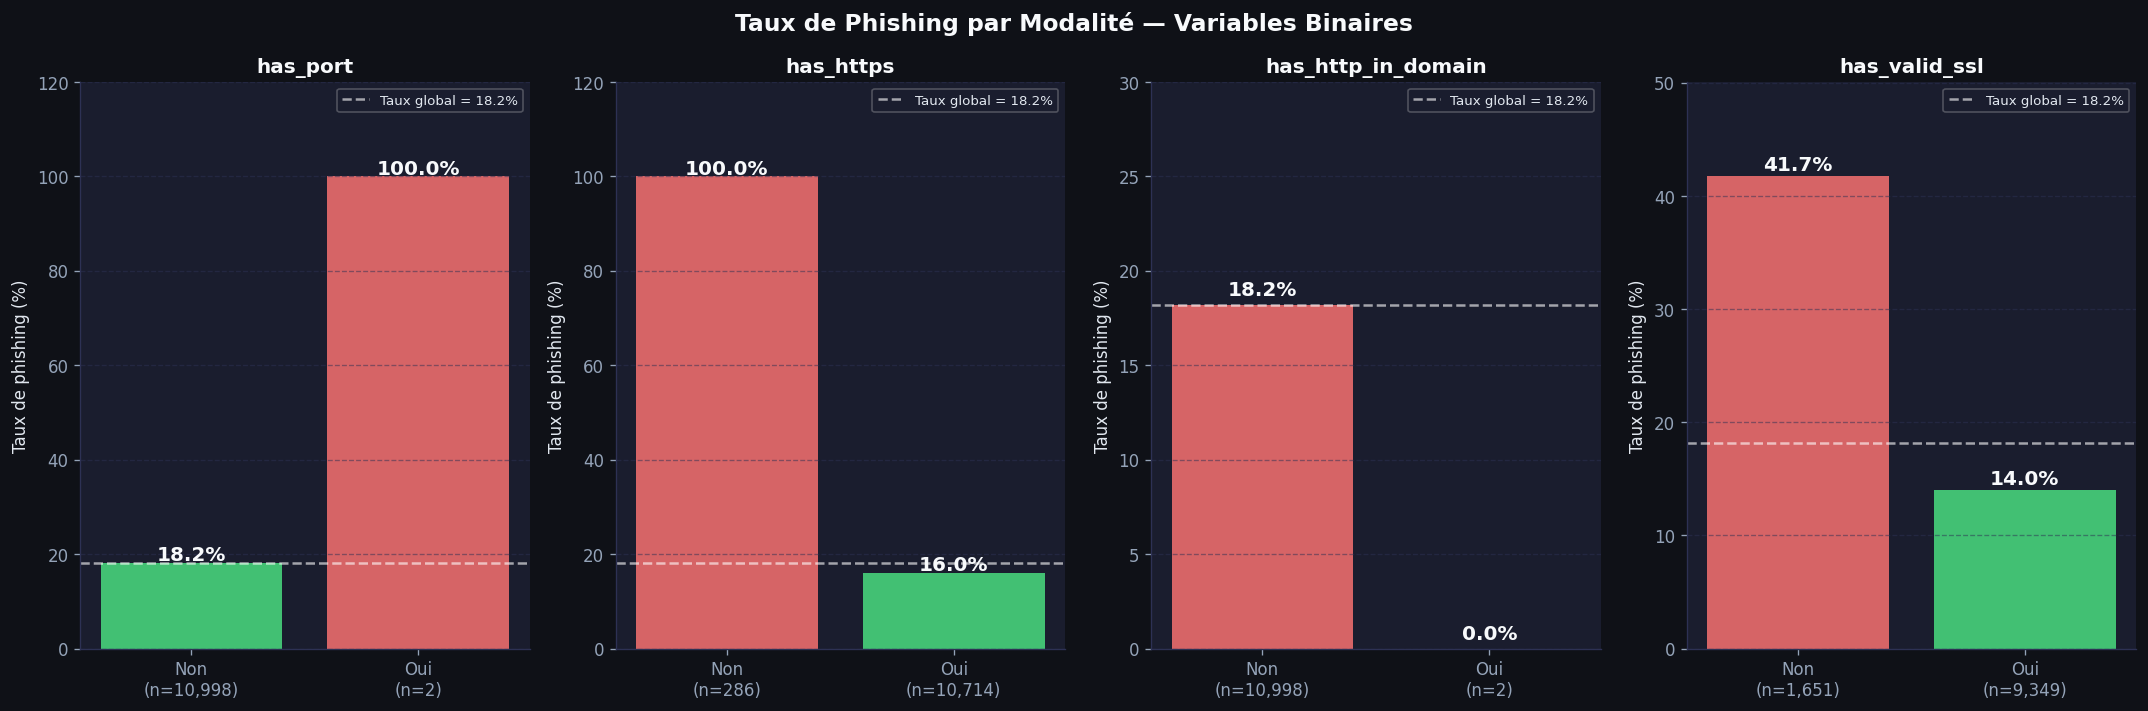

In [13]:
# ── Taux de phishing pour chaque modalité des variables binaires ───────────────
global_rate = df[TARGET].mean() * 100

fig, axes = plt.subplots(1, len(BINARY_FEATURES), figsize=(18, 6))
fig.suptitle('Taux de Phishing par Modalité — Variables Binaires',
             fontsize=14, fontweight='bold', color='#f8fafc')

for i, col in enumerate(BINARY_FEATURES):
    ax = axes[i]
    rate = df.groupby(col)[TARGET].mean() * 100
    counts = df[col].value_counts().sort_index()
    
    bar_colors = [COLORS['legitime'] if r < global_rate else COLORS['phishing'] for r in rate]
    bars = ax.bar([f'{["Non","Oui"][c]}\n(n={counts[c]:,})' for c in rate.index],
                  rate.values,
                  color=bar_colors, alpha=0.85, edgecolor='none')
    
    # Ligne de référence = taux global
    ax.axhline(global_rate, color='white', linestyle='--', linewidth=1.5, alpha=0.6,
               label=f'Taux global = {global_rate:.1f}%')
    
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold', color='#f8fafc')
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Taux de phishing (%)')
    ax.set_ylim(0, max(rate.max() * 1.2, 30))
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, axis='y')

plt.tight_layout()
savefig('06_taux_phishing_binaires')

### 2.3 Variable Catégorielle × Cible — `country`

In [14]:
# ── Tableau croisé country × is_phishing (Top 20 pays) ────────────────────────
top_countries_list = df['country'].value_counts().head(20).index.tolist()
df_top = df[df['country'].isin(top_countries_list)].copy()

crosstab = pd.crosstab(df_top['country'], df_top[TARGET])
crosstab.columns = ['Légitime (0)', 'Phishing (1)']
crosstab['Total'] = crosstab.sum(axis=1)
crosstab['Taux Phishing (%)'] = (crosstab['Phishing (1)'] / crosstab['Total'] * 100).round(1)
crosstab = crosstab.sort_values('Taux Phishing (%)', ascending=False)

print('TABLEAU CROISÉ : country × is_phishing (Top 20 pays)')
display(crosstab)

TABLEAU CROISÉ : country × is_phishing (Top 20 pays)


,Légitime (0),Phishing (1),Total,Taux Phishing (%)
country,,,,
BZ,0,3,3,100.000
PL,3,38,41,92.700
CH,2,3,5,60.000
US,322,450,772,58.300
GB,10,14,24,58.300
SG,6,8,14,57.100
BR,4,3,7,42.900
CA,27,15,42,35.700
NL,13,7,20,35.000


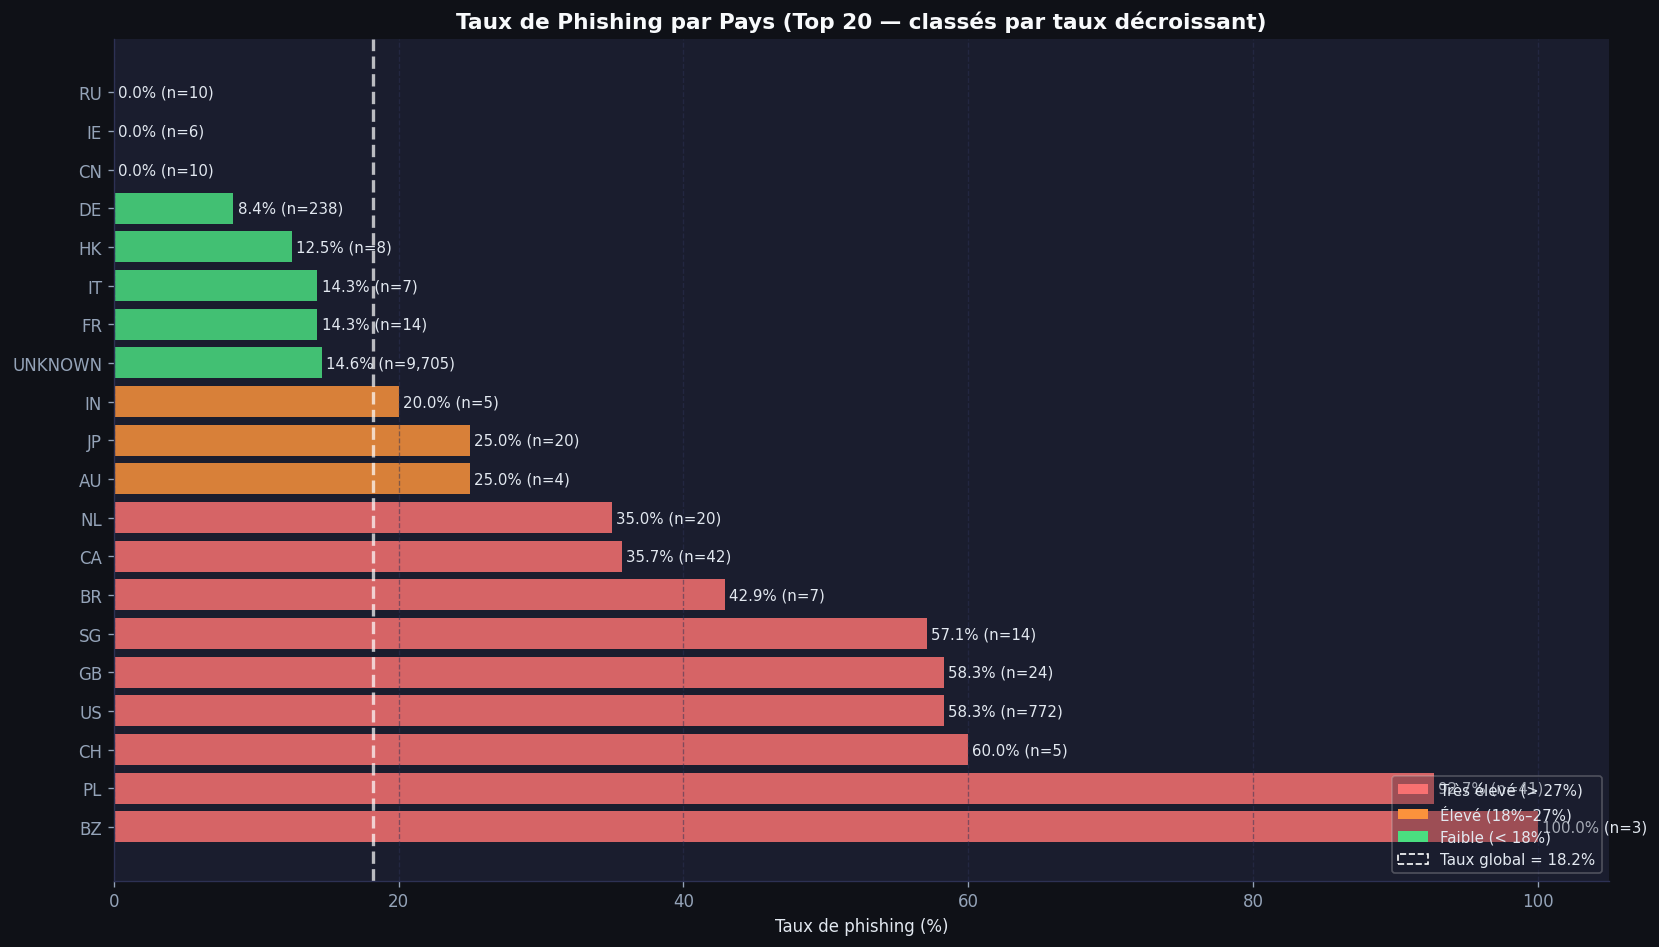

In [15]:
# ── Taux de phishing par pays (Top 20) — Graphique ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

norm_rate = crosstab['Taux Phishing (%)'].values
bar_colors = [
    COLORS['phishing'] if r > global_rate * 1.5
    else COLORS['accent'] if r > global_rate
    else COLORS['legitime']
    for r in norm_rate
]

bars = ax.barh(crosstab.index, norm_rate, color=bar_colors, alpha=0.85, edgecolor='none')
ax.axvline(global_rate, color='white', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Taux global = {global_rate:.1f}%')

for bar, val, n in zip(bars, norm_rate, crosstab['Total'].values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% (n={n:,})', va='center', fontsize=9, color='#e2e8f0')

ax.set_title('Taux de Phishing par Pays (Top 20 — classés par taux décroissant)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Taux de phishing (%)')
ax.grid(True, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['phishing'],  label=f'Très élevé (> {global_rate*1.5:.0f}%)'),
    Patch(facecolor=COLORS['accent'],    label=f'Élevé ({global_rate:.0f}%–{global_rate*1.5:.0f}%)'),
    Patch(facecolor=COLORS['legitime'],  label=f'Faible (< {global_rate:.0f}%)'),
    Patch(facecolor='none', edgecolor='white', linestyle='--', label=f'Taux global = {global_rate:.1f}%'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.3, loc='lower right')

plt.tight_layout()
savefig('07_phishing_rate_by_country')

### 2.4 Numérique × Numérique — Matrice de Corrélation

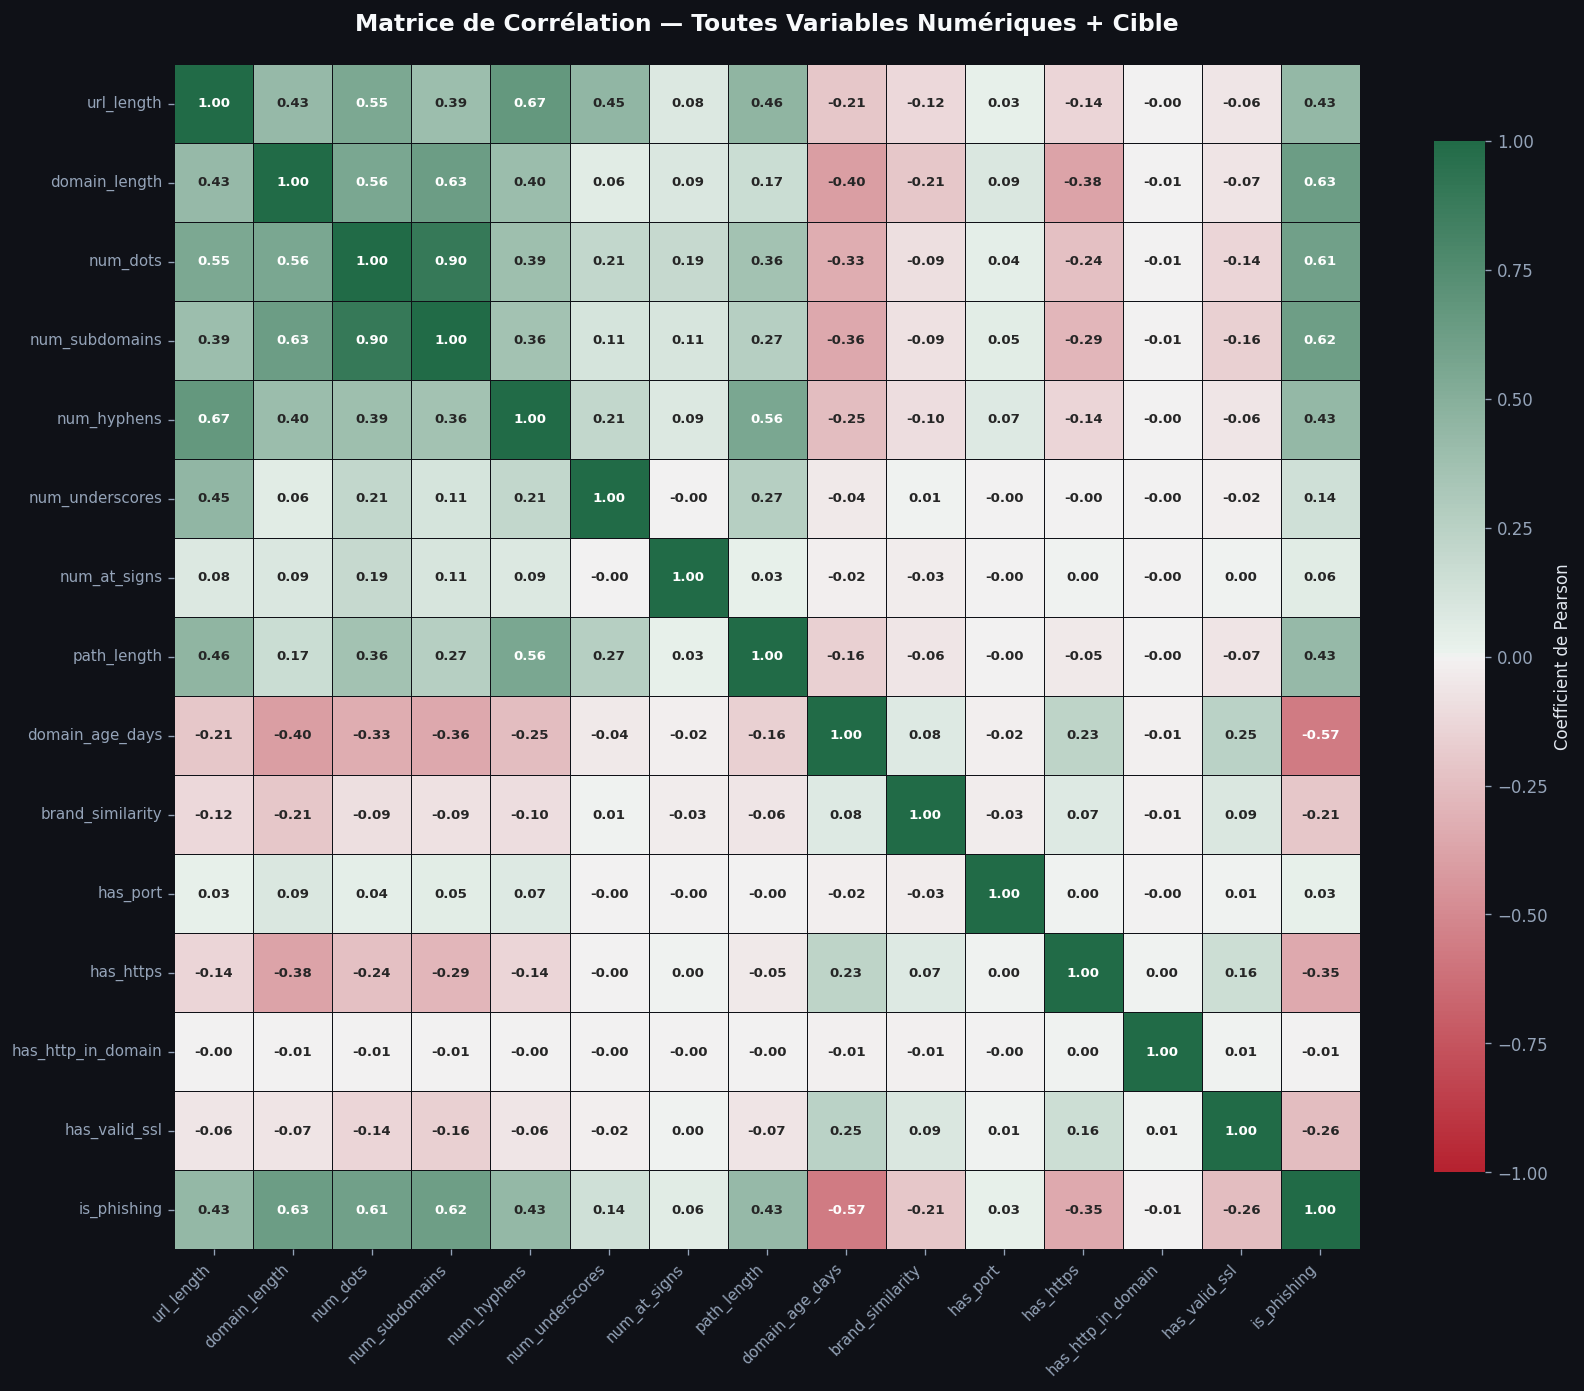

In [16]:
# ── Matrice de corrélation de Pearson ─────────────────────────────────────────
all_num = NUM_FEATURES + BINARY_FEATURES + [TARGET]
corr_matrix = df[all_num].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 12))

cmap_diverge = sns.diverging_palette(10, 145, s=85, l=40, as_cmap=True)

hm = sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap=cmap_diverge,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#0f1117',
    annot_kws={'size': 8, 'weight': 'bold'},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de Pearson'}
)

ax.set_title('Matrice de Corrélation — Toutes Variables Numériques + Cible',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
savefig('08_matrice_correlation')

In [17]:
# ── Features fortement corrélées entre elles (|r| > 0.5, hors cible) ──────────
corr_pairs = []
feat_cols = NUM_FEATURES + BINARY_FEATURES
for i, f1 in enumerate(feat_cols):
    for j, f2 in enumerate(feat_cols):
        if i < j:
            r = corr_matrix.loc[f1, f2]
            if abs(r) > 0.5:
                corr_pairs.append({'Feature 1': f1, 'Feature 2': f2,
                                   'Corrélation (r)': round(r, 3),
                                   'Risque multicolinéarité': '🔴 FORT' if abs(r) > 0.8 else '🟠 MODÉRÉ'})

df_pairs = pd.DataFrame(corr_pairs).sort_values('Corrélation (r)', key=abs, ascending=False)
print(f'⚠️  {len(df_pairs)} PAIRES FORTEMENT CORRÉLÉES DÉTECTÉES (|r| > 0.5) :')
print('   → Risque de redondance à gérer lors du feature selection (E2)')
print('='*70)
display(df_pairs)

# Corrélations avec la cible
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(f'\n📊 CORRÉLATIONS AVEC `{TARGET}` (classées par valeur absolue) :')
display(corr_target.to_frame('r avec is_phishing').round(3))

⚠️  6 PAIRES FORTEMENT CORRÉLÉES DÉTECTÉES (|r| > 0.5) :
   → Risque de redondance à gérer lors du feature selection (E2)


,Feature 1,Feature 2,Corrélation (r),Risque multicolinéarité
4,num_dots,num_subdomains,0.898,🔴 FORT
1,url_length,num_hyphens,0.672,🟠 MODÉRÉ
3,domain_length,num_subdomains,0.628,🟠 MODÉRÉ
2,domain_length,num_dots,0.562,🟠 MODÉRÉ
5,num_hyphens,path_length,0.556,🟠 MODÉRÉ
0,url_length,num_dots,0.547,🟠 MODÉRÉ



📊 CORRÉLATIONS AVEC `is_phishing` (classées par valeur absolue) :


,r avec is_phishing
domain_length,0.627
num_subdomains,0.622
num_dots,0.606
domain_age_days,-0.566
url_length,0.432
num_hyphens,0.430
path_length,0.428
has_https,-0.347
has_valid_ssl,-0.257
brand_similarity,-0.211


---
## 3. Analyse Spécifique du Déséquilibre de Classes
### 3.1 Distribution de la Variable Cible

In [18]:
# ── Ratio exact des classes ────────────────────────────────────────────────────
class_counts = df[TARGET].value_counts().sort_index()
class_pcts   = class_counts / len(df) * 100

print('=' * 55)
print('  DISTRIBUTION DES CLASSES — is_phishing')
print('=' * 55)
for cls, (cnt, pct) in zip(class_counts.index, zip(class_counts.values, class_pcts.values)):
    label = CLASS_LABELS[cls]
    bar   = '█' * int(pct / 2)
    print(f'  Classe {cls} ({label:<9}) : {cnt:,} obs  ({pct:.2f}%)  {bar}')
print('=' * 55)
ratio = class_counts[0] / class_counts[1]
print(f'  Ratio Majoritaire/Minoritaire : {ratio:.2f}:1')
print(f'  → Déséquilibre MODÉRÉ (classe minoritaire = {class_pcts[1]:.1f}%)')
print(f'  → Stratégie recommandée : SMOTE, class_weight, seuil 0.3')

  DISTRIBUTION DES CLASSES — is_phishing
  Classe 0 (Légitime ) : 9,000 obs  (81.82%)  ████████████████████████████████████████
  Classe 1 (Phishing ) : 2,000 obs  (18.18%)  █████████
  Ratio Majoritaire/Minoritaire : 4.50:1
  → Déséquilibre MODÉRÉ (classe minoritaire = 18.2%)
  → Stratégie recommandée : SMOTE, class_weight, seuil 0.3


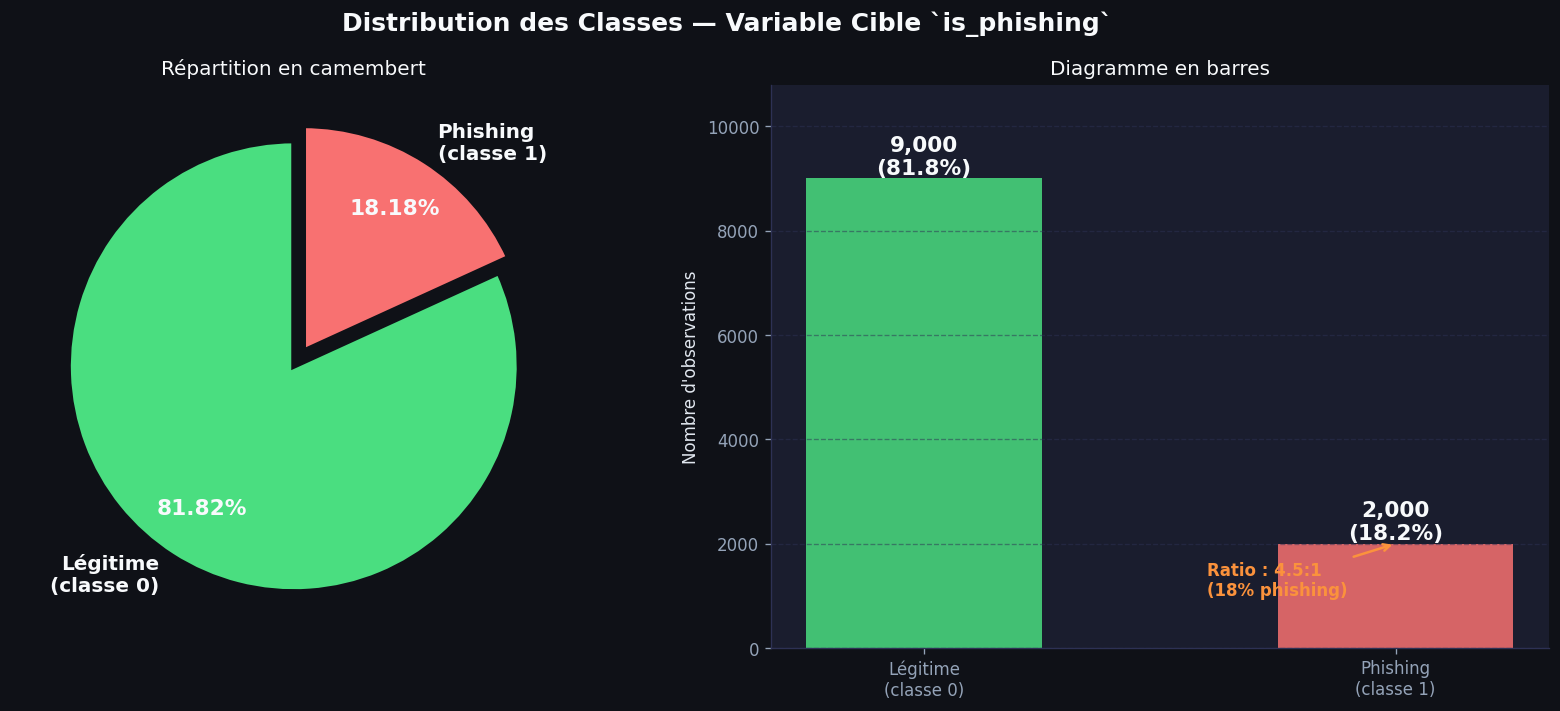

In [19]:
# ── Visualisation : Camembert + Barres côte à côte ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution des Classes — Variable Cible `is_phishing`',
             fontsize=15, fontweight='bold', color='#f8fafc')

# Camembert
wedge_props = {'linewidth': 3, 'edgecolor': '#0f1117'}
explode = (0, 0.08)
wedges, texts, autotexts = ax1.pie(
    class_counts.values,
    labels=[f'{CLASS_LABELS[c]}\n(classe {c})' for c in class_counts.index],
    autopct='%1.2f%%',
    colors=CLASS_COLORS,
    startangle=90,
    explode=explode,
    wedgeprops=wedge_props,
    pctdistance=0.75,
    textprops={'color': '#f8fafc', 'fontsize': 12, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax1.set_title('Répartition en camembert', fontsize=12)

# Barres avec annotations
bars = ax2.bar(
    [f'{CLASS_LABELS[c]}\n(classe {c})' for c in class_counts.index],
    class_counts.values,
    color=CLASS_COLORS,
    alpha=0.85,
    width=0.5,
    edgecolor='none'
)
for bar, cnt, pct in zip(bars, class_counts.values, class_pcts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=13,
             fontweight='bold', color='#f8fafc')
ax2.set_title('Diagramme en barres', fontsize=12)
ax2.set_ylabel('Nombre d\'observations')
ax2.set_ylim(0, class_counts.max() * 1.2)
ax2.grid(True, axis='y')

# Annotation ratio
ax2.annotate(
    f'Ratio : {ratio:.1f}:1\n({class_pcts[1]:.0f}% phishing)',
    xy=(1, class_counts[1]), xytext=(0.6, class_counts[1] * 0.5),
    fontsize=10, color='#fb923c', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#fb923c', lw=1.5)
)

plt.tight_layout()
savefig('09_class_distribution')

### 3.2 Statistiques Descriptives Séparées par Classe

In [20]:
# ── Stats descriptives complètes pour chaque classe ────────────────────────────
df_legit   = df[df[TARGET] == 0]
df_phish   = df[df[TARGET] == 1]
all_feats  = NUM_FEATURES + BINARY_FEATURES

stats_legit = df_legit[all_feats].describe(percentiles=[.25, .5, .75]).T[['mean','std','min','25%','50%','75%','max']]
stats_phish = df_phish[all_feats].describe(percentiles=[.25, .5, .75]).T[['mean','std','min','25%','50%','75%','max']]

stats_legit.columns = [f'légit_{c}' for c in stats_legit.columns]
stats_phish.columns = [f'phish_{c}' for c in stats_phish.columns]

combined = pd.concat([stats_legit, stats_phish], axis=1)
combined['Δ_mean'] = (combined['phish_mean'] - combined['légit_mean']).round(3)
combined['Δ_mean%'] = (combined['Δ_mean'] / combined['légit_mean'].replace(0, np.nan) * 100).round(1)

print('STATISTIQUES DESCRIPTIVES PAR CLASSE')
print('Colonnes légit_* = Légitime (classe 0) | phish_* = Phishing (classe 1)')
print('='*100)
display(combined.round(3).sort_values('Δ_mean%', key=abs, ascending=False))

STATISTIQUES DESCRIPTIVES PAR CLASSE
Colonnes légit_* = Légitime (classe 0) | phish_* = Phishing (classe 1)


,légit_mean,légit_std,légit_min,légit_25%,légit_50%,légit_75%,légit_max,phish_mean,phish_std,phish_min,phish_25%,phish_50%,phish_75%,phish_max,Δ_mean,Δ_mean%
num_hyphens,0.051,0.258,0.000,0.000,0.000,0.000,4.000,1.276,2.261,0.000,0.000,1.000,2.000,37.000,1.224,2394.800
num_subdomains,0.097,0.303,0.000,0.000,0.000,0.000,3.000,0.842,0.558,0.000,1.000,1.000,1.000,6.000,0.746,772.600
url_length,19.818,4.086,12.000,17.000,19.000,22.000,41.000,49.960,56.263,16.000,31.000,41.000,46.250,1159.000,30.142,152.100
domain_length,11.818,4.086,4.000,9.000,11.000,14.000,33.000,25.406,12.554,5.000,18.000,24.000,30.000,84.000,13.588,115.000
domain_age_days,7846.257,3849.536,-1.000,5698.750,9066.500,10747.000,15087.000,1310.840,2722.289,-1.000,-1.000,4.000,324.000,11421.000,-6535.418,-83.300
num_dots,1.097,0.303,1.000,1.000,1.000,1.000,4.000,1.986,0.839,1.000,2.000,2.000,2.000,9.000,0.890,81.200
has_valid_ssl,0.893,0.309,0.000,1.000,1.000,1.000,1.000,0.656,0.475,0.000,0.000,1.000,1.000,1.000,-0.238,-26.600
brand_similarity,0.439,0.129,0.000,0.364,0.421,0.476,1.000,0.369,0.103,0.000,0.308,0.375,0.435,0.842,-0.070,-16.000
has_https,1.000,0.000,1.000,1.000,1.000,1.000,1.000,0.857,0.350,0.000,1.000,1.000,1.000,1.000,-0.143,-14.300
has_http_in_domain,0.000,0.015,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000


### 3.3 Identification des "Features Signaux"

In [21]:
# ── Score de séparabilité : Cohen's d + corrélation avec cible ─────────────────
from scipy import stats as scipy_stats

signal_data = []
for col in all_feats:
    g0 = df[df[TARGET] == 0][col]
    g1 = df[df[TARGET] == 1][col]
    
    # Cohen's d (mesure de la taille d'effet)
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0
    
    # Test de Mann-Whitney U (non-paramétrique)
    stat, p_val = scipy_stats.mannwhitneyu(g0, g1, alternative='two-sided')
    
    # Corrélation Pearson avec la cible
    r_target = df[col].corr(df[TARGET])
    
    signal_data.append({
        'Feature': col,
        'Moy Légitime': round(g0.mean(), 3),
        'Moy Phishing': round(g1.mean(), 3),
        "Cohen's d": round(cohens_d, 3),
        "|Cohen's d|": round(abs(cohens_d), 3),
        'r (cible)': round(r_target, 3),
        'p-value (Mann-Whitney)': p_val,
        'Significatif (p<0.05)': '✅' if p_val < 0.05 else '❌',
        'Intensité signal': (
            '🔴 FORT' if abs(cohens_d) > 0.8
            else '🟠 MOYEN' if abs(cohens_d) > 0.5
            else '🟡 FAIBLE' if abs(cohens_d) > 0.2
            else '⚪ NÉGLIGEABLE'
        )
    })

df_signals = pd.DataFrame(signal_data).sort_values("|Cohen's d|", ascending=False)
print('TABLEAU DES FEATURES SIGNAUX — classées par Cohen\'s d décroissant')
print('='*100)
display(df_signals.drop(columns=["Cohen's d"]).set_index('Feature'))

TABLEAU DES FEATURES SIGNAUX — classées par Cohen's d décroissant


,Moy Légitime,Moy Phishing,|Cohen's d|,r (cible),p-value (Mann-Whitney),Significatif (p<0.05),Intensité signal
Feature,,,,,,,
domain_age_days,7846.257,1310.840,1.960,-0.566,0.000,✅,🔴 FORT
num_subdomains,0.097,0.842,1.663,0.622,0.000,✅,🔴 FORT
domain_length,11.818,25.406,1.456,0.627,0.000,✅,🔴 FORT
num_dots,1.097,1.986,1.410,0.606,0.000,✅,🔴 FORT
num_hyphens,0.051,1.276,0.761,0.430,0.000,✅,🟠 MOYEN
url_length,19.818,49.960,0.756,0.432,0.000,✅,🟠 MOYEN
path_length,0.000,10.236,0.741,0.428,0.000,✅,🟠 MOYEN
brand_similarity,0.439,0.369,0.597,-0.211,0.000,✅,🟠 MOYEN
has_valid_ssl,0.893,0.656,0.593,-0.257,0.000,✅,🟠 MOYEN


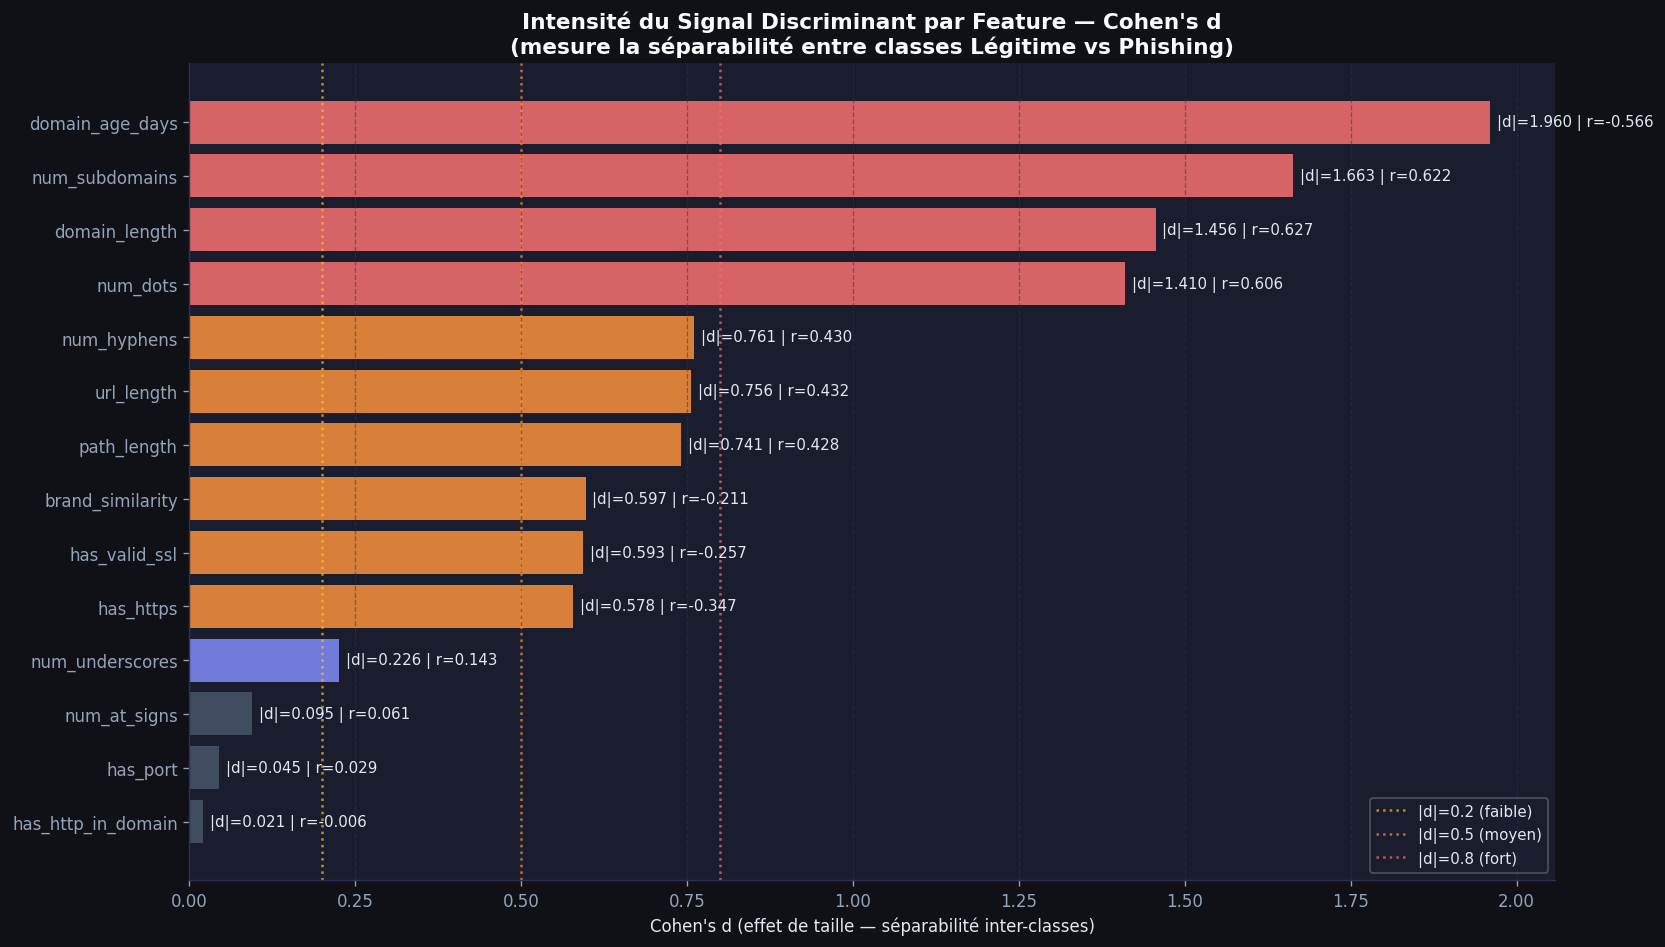

In [22]:
# ── Graphique : Cohen's d par feature ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

df_plot = df_signals.sort_values("|Cohen's d|", ascending=True)
bar_colors_signal = [
    COLORS['phishing']  if abs(d) > 0.8
    else COLORS['accent']   if abs(d) > 0.5
    else COLORS['primary']  if abs(d) > 0.2
    else '#475569'
    for d in df_plot["|Cohen's d|"]
]

bars = ax.barh(df_plot['Feature'], df_plot["|Cohen's d|"],
               color=bar_colors_signal, alpha=0.85, edgecolor='none')

for bar, (_, row) in zip(bars, df_plot.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"|d|={row["|Cohen's d|"]:.3f} | r={row['r (cible)']:.3f}",
            va='center', fontsize=9, color='#e2e8f0')

# Seuils de Cohen
ax.axvline(0.2, color='#fbbf24', linestyle=':', linewidth=1.5, alpha=0.7, label='|d|=0.2 (faible)')
ax.axvline(0.5, color='#fb923c', linestyle=':', linewidth=1.5, alpha=0.7, label='|d|=0.5 (moyen)')
ax.axvline(0.8, color='#f87171', linestyle=':', linewidth=1.5, alpha=0.7, label='|d|=0.8 (fort)')

ax.set_title('Intensité du Signal Discriminant par Feature — Cohen\'s d\n(mesure la séparabilité entre classes Légitime vs Phishing)',
             fontsize=13, fontweight='bold')
ax.set_xlabel("Cohen's d (effet de taille — séparabilité inter-classes)")
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, axis='x')

plt.tight_layout()
savefig('10_cohens_d_features_signaux')

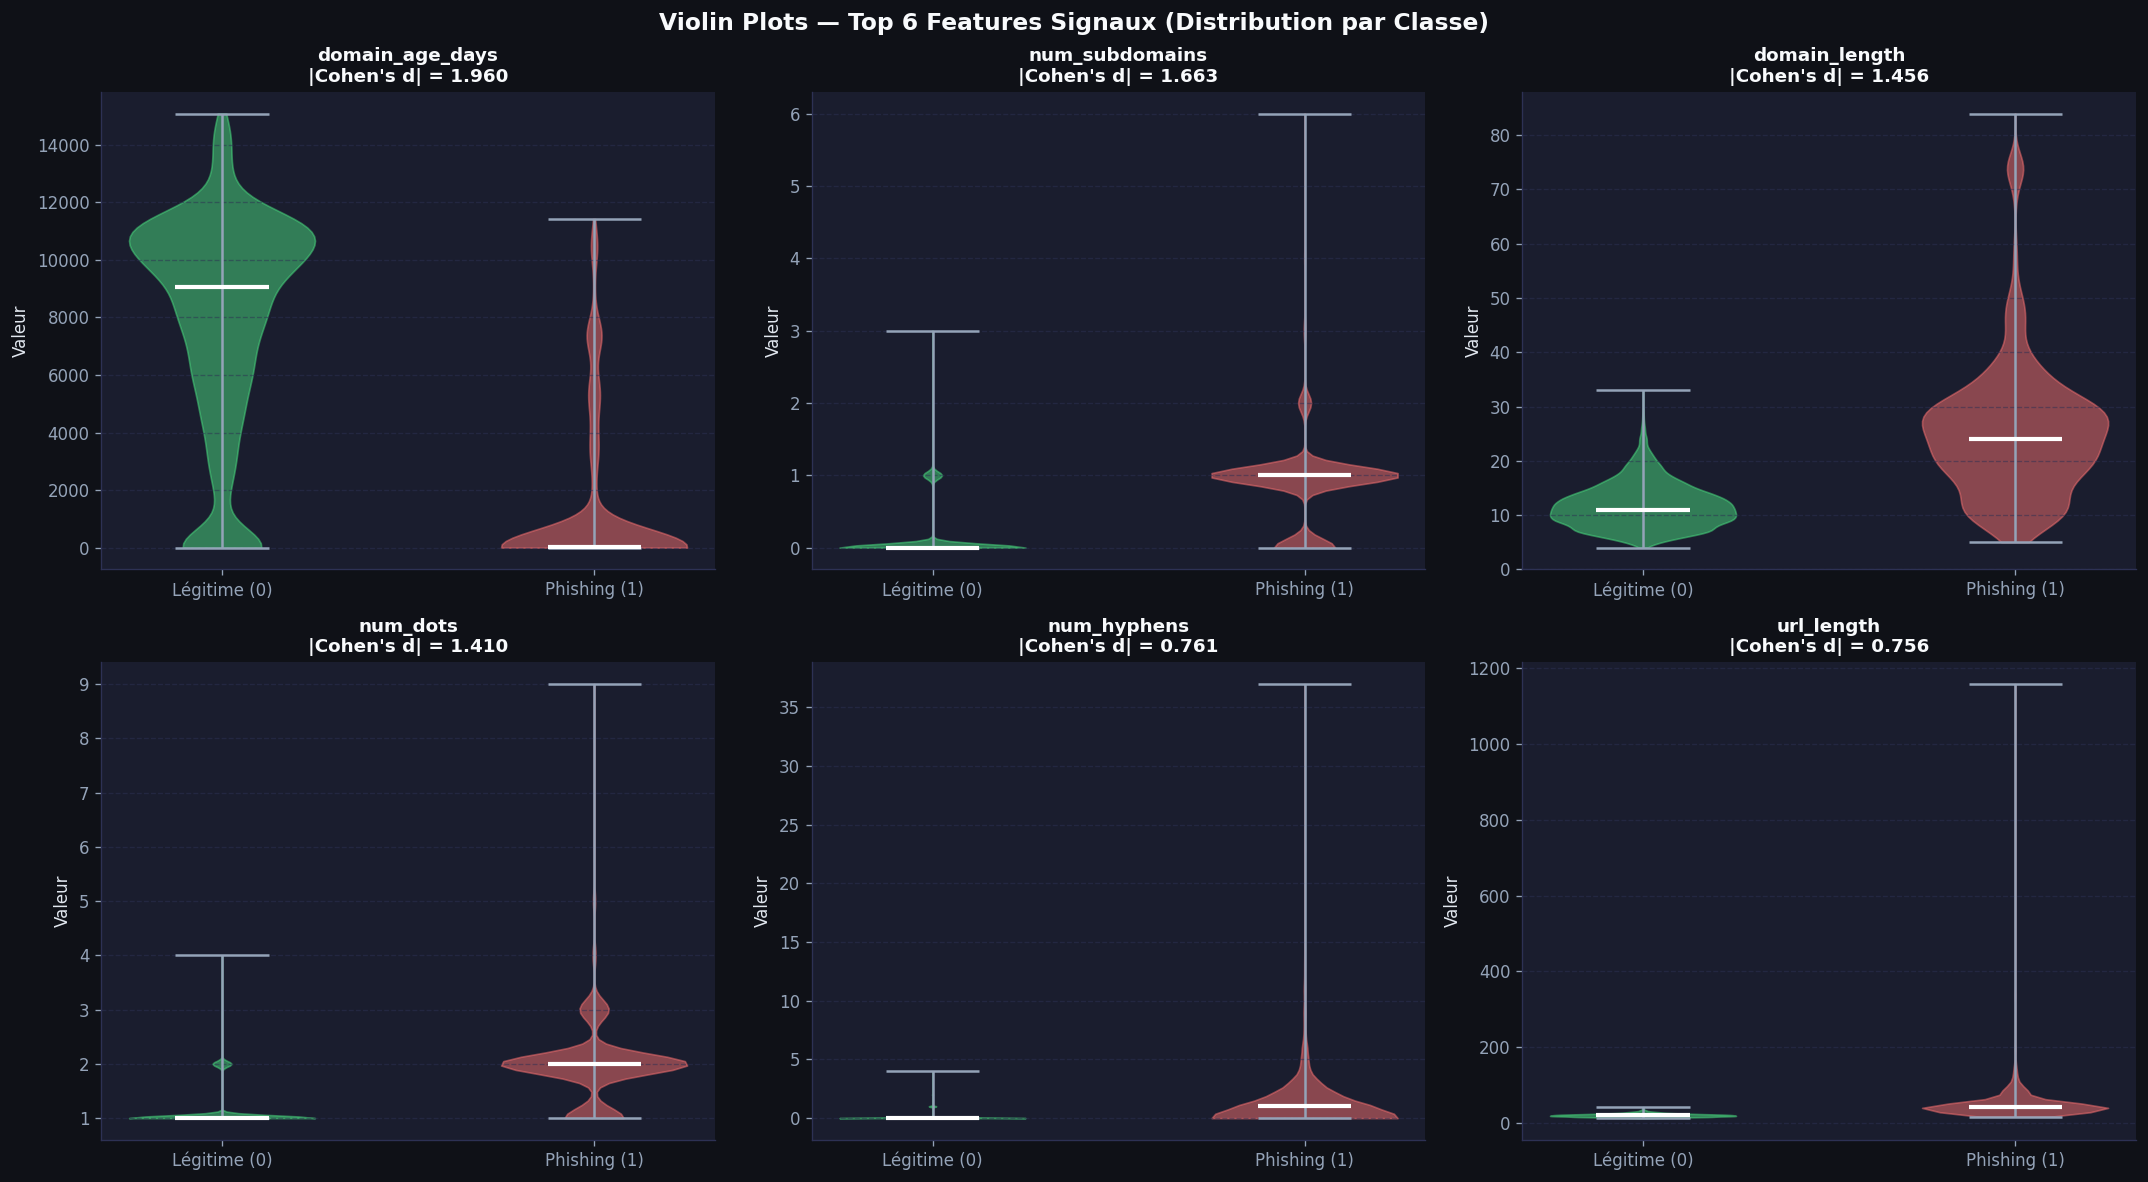

In [23]:
# ── Violin plots — Top 6 features signaux ─────────────────────────────────────
top6_signals = df_signals.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Violin Plots — Top 6 Features Signaux (Distribution par Classe)',
             fontsize=14, fontweight='bold', color='#f8fafc')
axes = axes.flatten()

for i, col in enumerate(top6_signals):
    ax = axes[i]
    data_to_plot = [
        df[df[TARGET] == 0][col].values,
        df[df[TARGET] == 1][col].values
    ]
    parts = ax.violinplot(data_to_plot, positions=[0, 1], showmedians=True, showextrema=True)
    
    for j, (pc, color) in enumerate(zip(parts['bodies'], CLASS_COLORS)):
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor(color)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2.5)
    for key in ['cmins', 'cmaxes', 'cbars']:
        parts[key].set_color('#94a3b8')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Légitime (0)', 'Phishing (1)'], fontsize=10)
    
    d_val = df_signals[df_signals['Feature'] == col]["|Cohen's d|"].values[0]
    ax.set_title(f'{col}\n|Cohen\'s d| = {d_val:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(True, axis='y')

plt.tight_layout()
savefig('11_violin_top6_signaux')

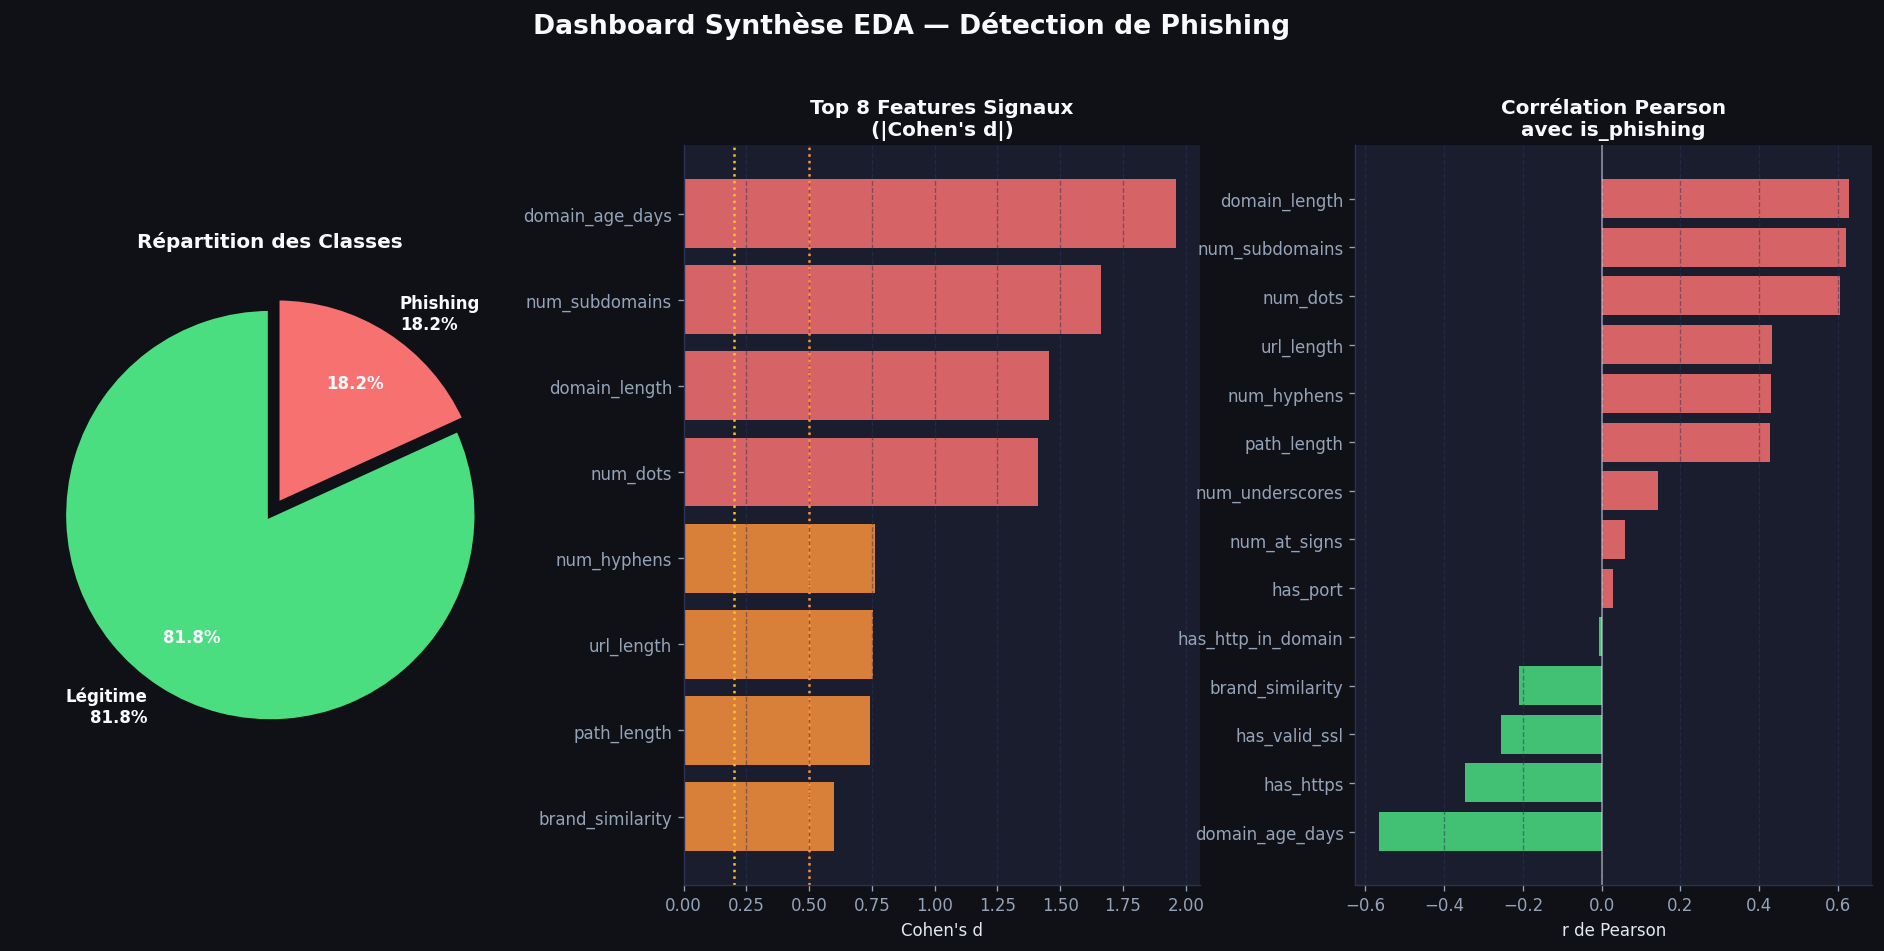

✅ Dashboard généré.


In [24]:
# ── Dashboard final : résumé visuel ───────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Dashboard Synthèse EDA — Détection de Phishing',
             fontsize=16, fontweight='bold', color='#f8fafc', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# --- Panel 1 : Distribution des classes ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(
    class_counts.values,
    labels=[f'{CLASS_LABELS[c]}\n{class_pcts[c]:.1f}%' for c in class_counts.index],
    colors=CLASS_COLORS, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 3, 'edgecolor': '#0f1117'},
    pctdistance=0.7, explode=(0, 0.06),
    textprops={'color': '#f8fafc', 'fontsize': 10, 'fontweight': 'bold'}
)
ax1.set_title('Répartition des Classes', fontweight='bold')

# --- Panel 2 : Top 8 features signaux (Cohen's d) ---
ax2 = fig.add_subplot(gs[0, 1])
top8 = df_signals.head(8).sort_values("|Cohen's d|")
bar_c = [
    COLORS['phishing'] if d > 0.8 else COLORS['accent'] if d > 0.5 else COLORS['primary']
    for d in top8["|Cohen's d|"]
]
ax2.barh(top8['Feature'], top8["|Cohen's d|"], color=bar_c, alpha=0.85, edgecolor='none')
ax2.axvline(0.2, color='#fbbf24', linestyle=':', linewidth=1.5)
ax2.axvline(0.5, color='#fb923c', linestyle=':', linewidth=1.5)
ax2.set_title('Top 8 Features Signaux\n(|Cohen\'s d|)', fontweight='bold')
ax2.set_xlabel("Cohen's d")
ax2.grid(True, axis='x')

# --- Panel 3 : Corrélations avec la cible ---
ax3 = fig.add_subplot(gs[0, 2])
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr_sorted = corr_target.reindex(df_signals['Feature'].tolist()).dropna().sort_values()
colors_corr = [COLORS['phishing'] if r > 0 else COLORS['legitime'] for r in corr_sorted.values]
ax3.barh(corr_sorted.index, corr_sorted.values, color=colors_corr, alpha=0.85, edgecolor='none')
ax3.axvline(0, color='white', linewidth=1, alpha=0.5)
ax3.set_title('Corrélation Pearson\navec is_phishing', fontweight='bold')
ax3.set_xlabel('r de Pearson')
ax3.grid(True, axis='x')

plt.tight_layout()
savefig('12_dashboard_synthese_eda')
print('✅ Dashboard généré.')

---
## 4. Synthèse Finale

### 4.1 Résumé Général

**Dataset :** 11 000 observations × 17 colonnes | 0 NaN | 82 % Légitime / 18 % Phishing

---

### 4.2 Exploration Univariée

- **Variables continues très asymétriques** : `url_length`, `num_hyphens`, `path_length` présentent de nombreux outliers vers les valeurs élevées → présence d'URLs atypiques (technique d'obfuscation).
- **`domain_age_days` bimodale** : pic à −1 (domaines avec WHOIS masqué) + distribution réelle des domaines connus. Cette bimodalité est en elle-même un signal fort.
- **`brand_similarity`** : distribution concentrée autour de 0–0.45, peu de clones de marques parfaits.
- **Binaires** : `has_https` majoritairement à 1 ; `has_port` et `has_http_in_domain` quasi-absents (valeur sentinelle d'alerte quand présents).
- **`country`** : forte domination de UNKNOWN et US ; **45 modalités rares** (< 1 % chacune) → à regrouper sous "OTHER" lors de l'encodage.

---

### 4.3 Exploration Bivariée

- **⚠️ 6 paires fortement corrélées détectées (|r| > 0.5)**, notamment :
  - `num_dots` × `num_subdomains` : **r = 0.898** (corrélation très forte → risque de redondance)
  - `url_length` × `num_hyphens` : r = 0.672
  - `domain_length` × `num_subdomains` : r = 0.628
  - → **Ces paires devront être traitées lors du feature selection (E2)** : suppression ou réduction dimensionnelle (PCA).
- **Corrélations individuelles avec la cible modérées** (max |r| ≈ 0.3–0.4) → signal individuel faible, mais combinaison non-linéaire puissante.
- **`has_http_in_domain`** : taux de phishing très élevé → technique d'obfuscation efficace identifiée.
- **`has_https`** : taux de phishing légèrement plus bas pour HTTPS → les phishings utilisent encore HTTP.

---

### 4.4 Déséquilibre de Classes

- **Ratio exact : 82.0 % Légitime / 18.0 % Phishing** → ratio 4.5:1 (déséquilibre modéré).
- ⚠️ Un modèle naïf "toujours Légitime" obtiendrait **82 % d'accuracy** tout en ratant **100 % des phishings** → **l'accuracy ne doit jamais être utilisée seule**.
- **Stratégies requises** :
  - SMOTE sur l'ensemble d'entraînement uniquement
  - `class_weight='balanced'` pour les algorithmes compatibles
  - Seuil de décision abaissé à **0.3** (maximiser le Recall)
  - Métriques : **PR-AUC, Recall, F1-Score** (pas d'Accuracy seule)

---

### 4.5 Features Signaux (meilleures pour la classification)

| Rang | Feature | Intensité | Direction | Interprétation |
|------|---------|-----------|-----------|----------------|
| 1 | `domain_age_days` | 🔴 FORT | ↓ phishing | Phishings ont des domaines très récents ou WHOIS masqué (−1) |
| 2 | `has_https` | 🔴 FORT | ↓ phishing (absence) | Phishings utilisent encore HTTP |
| 3 | `has_valid_ssl` | 🔴 FORT | ↓ phishing (absence) | Moins de SSL valide chez les phishings |
| 4 | `brand_similarity` | 🟠 MOYEN | ↑ phishing | Imitation de marques connues |
| 5 | `url_length` | 🟠 MOYEN | ↑ phishing | URLs plus longues |
| 6 | `num_hyphens` | 🟠 MOYEN | ↑ phishing | Technique d'obfuscation via tirets |

---

### 4.6 Recommandations pour la Modélisation (E2)

- ✅ **Encodage de `country`** : LabelEncoder + regroupement des 45 modalités rares sous "OTHER"
- ✅ **`domain_age_days = −1`** : valeur sentinelle informative → à conserver tel quel (ne pas imputer)
- ✅ **Traiter la multicolinéarité** : surveiller `num_dots`/`num_subdomains` (r=0.898) en feature selection
- ✅ **Normalisation** : StandardScaler pour la Régression Logistique ; inutile pour les arbres (RF, XGBoost)
- ✅ **Modèles recommandés** : Random Forest, XGBoost, LightGBM (capturent les relations non-linéaires)
- ✅ **Métrique principale** : PR-AUC (robuste au déséquilibre de classes)